# 1) Imports & chargement

In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import joblib

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import KNNImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.exceptions import NotFittedError
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text

import folium
from folium import LayerControl

In [29]:
df_ventes = pd.read_csv('data/ech_annonces_ventes_68.csv', sep=';', index_col='idannonce')

# 2) Nettoyage et conversion de float à int

In [30]:
def clean_df(df: pd.DataFrame):
    # On supprime les colonnes ayant plus de 80% de valeurs manquantes
    valeurs_manquantes = df.isna().sum()/df.shape[0]
    valeurs_manquantes_list = list(valeurs_manquantes[valeurs_manquantes > 0.8].index)
    df_filtered = df.drop(valeurs_manquantes_list, axis = 1)
    # On supprime les colonnes "n6" pour ne laisser que les "n7" qui paraissent plus judicieuses (basées sur un plus grand nombre de bien)
    column_n6 = [ column for column in df_filtered.columns if "n6" in column]
    df_filtered = df_filtered.drop(column_n6, axis = 1)
    if 'typedebien' in df_filtered.columns:
        df_filtered = df_filtered[df_filtered['typedebien'] != 'l']
        df_filtered['typedebien'] = df_filtered['typedebien'].replace({'an': 'a', 'mn': 'm'})

    # On transform en Int des colonnes déclarées en float mais n'ayant que des int
    valeurs_manq_resid_quanti = [col for  col in df_filtered.select_dtypes(exclude='object').columns if df_filtered[col].isna().sum() > 0]    
    col_float = df_filtered[valeurs_manq_resid_quanti].select_dtypes(include='float64').columns
    for col in col_float:
        array_col = np.array(df_filtered[df_filtered[col].notna()][col]) 
        array_col_round = np.round(array_col)
        array_real_float = array_col[array_col != array_col_round]
        if len(array_real_float) == 0:
            df_filtered[col] = df_filtered[col].astype('Int64')
    # on transforme les colonnes quali n'ayant en fait que deux modalités
    if 'cave' in df_filtered.columns:
        df_filtered["cave"] = df_filtered["cave"].astype('Int64')
    if 'ascenseur' in df_filtered.columns:
        df_filtered["ascenseur"] = df_filtered["ascenseur"].astype('Int64')
    if 'logement_neuf' in df_filtered.columns:
        df_filtered["logement_neuf"] = df_filtered["logement_neuf"].replace({'n': False, 'o': True}).astype('Int64')

    return df_filtered

In [31]:
df_ventes = clean_df(df_ventes)
target = df_ventes['prix_bien']

# 3) Split train/test

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    df_ventes.drop(columns=['prix_bien']),
    target,
    test_size=0.2,
    random_state=42
)

# 4) Transformer pour le remplissage (quali et quanti) du dataframe

In [33]:
class KNNImputerCustom(BaseEstimator, TransformerMixin):
    def __init__(self, type_col="typedebien", lat_col="mapCoordonneesLatitude", lon_col="mapCoordonneesLongitude", pieces_col="nb_pieces", k=10):
        self.type_col = type_col
        self.lat_col = lat_col
        self.lon_col = lon_col
        self.pieces_col = pieces_col
        self.k = k
        self.fitted = False
 
    def fit(self, X, y=None):
        self.df_train_ = X.copy()
        self.numeric_cols_ = X.select_dtypes(exclude="object").columns.tolist()
        self.default_mean_ = {col: X[col].mean() for col in self.numeric_cols_}
        self.imputer_ = KNNImputer()
        self.quali_cols_ = X.select_dtypes(include="object").columns.tolist()
        self.default_mode_ = {col: X[col].mode()[0] for col in self.quali_cols_}
        self.fitted = True
        
        return self
 
    def transform(self, X):
        if not(self.fitted):
            raise NotFittedError("This KNNImputerCustomed instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.")
        X = X.copy()
        # First we fill the numeric columns
        for col in self.numeric_cols_:
            if X[col].isna().sum() == 0:
                continue
            cols = [col, self.pieces_col, self.lat_col, self.lon_col]
            df_extract = X[[self.type_col] + cols]
            df_extract_train = self.df_train_ [[self.type_col] + cols]
            for typ in ["a", "m"]:
                subset = df_extract[df_extract[self.type_col] == typ][cols]
                if subset.shape[0] == 0:
                    continue
                apply_default = True
                subset_train = df_extract_train[df_extract_train[self.type_col] == typ][cols]
                if subset_train.shape[0] != 0:
                    self.imputer_.fit(subset_train)
                    imputed = self.imputer_.transform(subset)
                    if imputed.shape[1] == len(cols):
                        imputed_df = pd.DataFrame(imputed, columns=cols, index=subset.index)
                        apply_default = False
                if apply_default:
                    if X[col].dtype in ["int64", "Int64"]:
                        X.loc[subset.index, col] = self.default_mean_[col].astype("int64")
                    else:
                        X.loc[subset.index, col] = self.default_mean_[col]
                else:
                    if X[col].dtype in ["int64", "Int64"]:
                        X.loc[imputed_df.index, col] = imputed_df[col].round().astype("int64")
                    else:
                        X.loc[imputed_df.index, col] = imputed_df[col]

        #Secondly we fill the qualitative columns
        index_na = X[X[self.quali_cols_].isna().any(axis=1)].index
        for idx in index_na:
            lat = X.loc[idx, self.lat_col]
            lon = X.loc[idx, self.lon_col]
            nbp = X.loc[idx, self.pieces_col]
            typ = X.loc[idx, self.type_col]
            neighbours = self.df_train_[
                (self.df_train_[self.pieces_col] == nbp) &
                (self.df_train_[self.type_col] == typ)
            ]
            distances = (lat - neighbours[self.lat_col])**2 + (lon - neighbours[self.lon_col])**2
            for col in self.quali_cols_:
                if pd.isna(X.loc[idx, col]):
                    valid = neighbours[neighbours[col].notna()]
                    if valid.shape[0] > 0:
                        idx_neigh = distances[valid.index].sort_values().iloc[:self.k].index
                        X.loc[idx, col] = neighbours.loc[idx_neigh][col].mode()[0]
                    else:
                        X.loc[idx, col] = self.default_mode_[col]
        
        return X

In [34]:
knn_imputer_custom = KNNImputerCustom()
X_train = knn_imputer_custom.fit_transform(X_train)
X_test = knn_imputer_custom.transform(X_test)

# 5) Fonction de nettoyage des outiliers (IQR)

In [35]:
# Suppression de certains champs dont nous ne connaissons pas la définition
X_train.drop(columns=['duree_int', 'loyer_m2_median_n7', 'nb_log_n7', 'taux_rendement_n7'], axis=1, inplace=True)
X_test.drop(columns=['duree_int', 'loyer_m2_median_n7', 'nb_log_n7', 'taux_rendement_n7'], axis=1, inplace=True)

In [36]:
X_train_clean = X_train

numeric_cols = X_train.select_dtypes(include=['number']).columns.tolist()

index_to_drop = []

for col in numeric_cols:
    q1 = max(X_train[col].quantile(0.1), 0)
    q3 = max(X_train[col].quantile(0.9), 0)
    iqr = q3 - q1
    lower = max(q1 - 2 * iqr, 0)
    upper = max(q3 + 2 * iqr, 0)
    temp_index_to_drop = X_train[(X_train[col] < lower) | (X_train[col] > upper)].index.to_list()
    index_to_drop.extend(temp_index_to_drop)
    print("Suppression des lignes où ", col , " < ", lower, " ou ", col, " > ", upper, " (", len(temp_index_to_drop), " rows)")

X_train_clean = X_train_clean.drop(index_to_drop)

nb_rows_avant = X_train.shape[0]
nb_rows_apres = X_train_clean.shape[0]
nb_rows_suppr = nb_rows_avant - nb_rows_apres

print("\ndataframe initial : ", nb_rows_avant, " rows.")
print("dataframe nettoyé avec iqr : ", nb_rows_apres, " rows.")
print("Proportion conservé : ", 100 * np.round(nb_rows_apres/nb_rows_avant, 5), "%")
print("Nombre d'observations supprimées : ", nb_rows_suppr)

X_train = X_train_clean
y_train = y_train.loc[X_train.index]

Suppression des lignes où  etage  <  0  ou  etage  >  6.0  ( 272  rows)
Suppression des lignes où  surface  <  0  ou  surface  >  421.0  ( 105  rows)
Suppression des lignes où  surface_terrain  <  0  ou  surface_terrain  >  2850.0  ( 351  rows)
Suppression des lignes où  nb_pieces  <  0  ou  nb_pieces  >  17.0  ( 47  rows)
Suppression des lignes où  mensualiteFinance  <  0.0  ou  mensualiteFinance  >  0.0  ( 331  rows)
Suppression des lignes où  balcon  <  0  ou  balcon  >  3.0  ( 3  rows)
Suppression des lignes où  eau  <  0  ou  eau  >  3.0  ( 16  rows)
Suppression des lignes où  bain  <  0  ou  bain  >  3.0  ( 89  rows)
Suppression des lignes où  dpeC  <  0  ou  dpeC  >  745.8  ( 13  rows)
Suppression des lignes où  mapCoordonneesLatitude  <  46.595870000000005  ou  mapCoordonneesLatitude  >  49.07131999999999  ( 0  rows)
Suppression des lignes où  mapCoordonneesLongitude  <  6.43378  ou  mapCoordonneesLongitude  >  8.263480000000001  ( 0  rows)
Suppression des lignes où  nb_etages 

In [37]:
X_test_clean = X_test

numeric_cols = X_test.select_dtypes(include=['number']).columns.tolist()

index_to_drop = []

for col in numeric_cols:
    q1 = max(X_test[col].quantile(0.1), 0)
    q3 = max(X_test[col].quantile(0.9), 0)
    iqr = q3 - q1
    lower = max(q1 - 2 * iqr, 0)
    upper = max(q3 + 2 * iqr, 0)
    temp_index_to_drop = X_test[(X_test[col] < lower) | (X_test[col] > upper)].index.to_list()
    index_to_drop.extend(temp_index_to_drop)
    print("Suppression des lignes où ", col , " < ", lower, " ou ", col, " > ", upper, " (", len(temp_index_to_drop), " rows)")

X_test_clean = X_test_clean.drop(index_to_drop)

nb_rows_avant = X_test.shape[0]
nb_rows_apres = X_test_clean.shape[0]
nb_rows_suppr = nb_rows_avant - nb_rows_apres

print("\ndataframe initial : ", nb_rows_avant, " rows.")
print("dataframe nettoyé avec iqr : ", nb_rows_apres, " rows.")
print("Proportion conservé : ", 100 * np.round(nb_rows_apres/nb_rows_avant, 5), "%")
print("Nombre d'observations supprimées : ", nb_rows_suppr)

X_test = X_test_clean
y_test = y_test.loc[X_test.index]

Suppression des lignes où  etage  <  0  ou  etage  >  6.0  ( 85  rows)
Suppression des lignes où  surface  <  0  ou  surface  >  430.0  ( 26  rows)
Suppression des lignes où  surface_terrain  <  0  ou  surface_terrain  >  2857.5868  ( 85  rows)
Suppression des lignes où  nb_pieces  <  0  ou  nb_pieces  >  17.0  ( 12  rows)
Suppression des lignes où  mensualiteFinance  <  0.0  ou  mensualiteFinance  >  0.0  ( 88  rows)
Suppression des lignes où  balcon  <  0  ou  balcon  >  3.0  ( 1  rows)
Suppression des lignes où  eau  <  0  ou  eau  >  3.0  ( 4  rows)
Suppression des lignes où  bain  <  0  ou  bain  >  3.0  ( 22  rows)
Suppression des lignes où  dpeC  <  0  ou  dpeC  >  748.9800000000002  ( 3  rows)
Suppression des lignes où  mapCoordonneesLatitude  <  46.59563  ou  mapCoordonneesLatitude  >  49.07168  ( 0  rows)
Suppression des lignes où  mapCoordonneesLongitude  <  6.445864  ou  mapCoordonneesLongitude  >  8.251978999999999  ( 0  rows)
Suppression des lignes où  nb_etages  <  0  ou

# 6) Normalisation des données GPS (fit sur train)

In [38]:
scaler_lat = StandardScaler()
scaler_lon = StandardScaler()

X_train['Latitude_scaled']  = scaler_lat.fit_transform(X_train[['mapCoordonneesLatitude']])
X_train['Longitude_scaled'] = scaler_lon.fit_transform(X_train[['mapCoordonneesLongitude']])

X_test['Latitude_scaled']  = scaler_lat.transform(X_test[['mapCoordonneesLatitude']])
X_test['Longitude_scaled'] = scaler_lon.transform(X_test[['mapCoordonneesLongitude']])

# 7) Target Encoding (fit sur train)

In [39]:
cols_te = ['INSEE_COM', 'typedebien_lite', 'nb_pieces']

mean_price_by_combo = (
    X_train.assign(prix_bien=y_train)
    .groupby(cols_te, as_index=False)['prix_bien']
    .mean()
    .rename(columns={'prix_bien': 'prix_bien_target_encoding'})
)
indexes_train = X_train.index
indexes_test = X_test.index
X_train = X_train.merge(mean_price_by_combo, on=cols_te, how='left').set_index(indexes_train)
X_test  = X_test.merge(mean_price_by_combo, on=cols_te, how='left').set_index(indexes_test)

X_test[['prix_bien_target_encoding']] = X_test[['prix_bien_target_encoding']].fillna(y_train.mean())

In [40]:
X_train.head(3)

,type_annonceur,typedebien,typedetransaction,etage,surface,surface_terrain,nb_pieces,mensualiteFinance,balcon,eau,...,TYP_IRIS_x,TYP_IRIS_y,GRD_QUART,UU2010,REG,DEP,prix_m2_vente,Latitude_scaled,Longitude_scaled,prix_bien_target_encoding
idannonce,,,,,,,,,,,,,,,,,,,,,
ag681108-285757544,pr,a,v,1,74,454.206,3,0,0,0,...,Z,Z,6813500,68403,44,68,2814.86,-1.268439,1.437389,258272.800000
ag680297-340567902,pr,m,v,0,122,1239.000,5,0,0,1,...,H,H,6831501,68401,44,68,3114.75,0.502046,-0.903823,306629.411765
hektor-girardi-pfastatt-2683,pr,m,v,0,167,560.000,5,0,0,0,...,Z,Z,6804100,68000,44,68,772.46,0.412261,1.455061,298247.958333


# 8) Extraction année + OHE (fit sur train)

In [41]:
X_train['date'] = pd.to_datetime(X_train['date'])
X_test['date'] = pd.to_datetime(X_test['date'])

X_train['annee'] = X_train['date'].dt.year
X_test['annee'] = X_test['date'].dt.year

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
annee_train = ohe.fit_transform(X_train[['annee']])
annee_test  = ohe.transform(X_test[['annee']])

annee_cols = ohe.get_feature_names_out(['annee'])

X_train = pd.concat([X_train, pd.DataFrame(annee_train, columns=annee_cols, index=X_train.index)], axis=1)
X_test  = pd.concat([X_test,  pd.DataFrame(annee_test,  columns=annee_cols, index=X_test.index)], axis=1)

# 9) Parsing exposition / chauffage / DPE / GES

In [42]:
def parse_exposition(df):
    df = df.copy()
    df['exposition_clean'] = (
        df['exposition'].astype(str)
        .str.lower()
        .str.replace(r'[,/\\\-]', ' ', regex=True)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )
    df['expo_nord']  = df['exposition_clean'].str.contains(r'\bnord\b',  na=False).astype(int)
    df['expo_sud']   = df['exposition_clean'].str.contains(r'\bsud\b',   na=False).astype(int)
    df['expo_est']   = df['exposition_clean'].str.contains(r'\best\b',   na=False).astype(int)
    df['expo_ouest'] = df['exposition_clean'].str.contains(r'\bouest\b', na=False).astype(int)
    df['expo_inconnue'] = df['exposition_clean'].str.contains(r'0|nan', na=False).astype(int)
    return df

In [43]:
def parse_chauffage_systeme(df):
    df = df.copy()
    df['chauffage_systeme_clean'] = (
        df['chauffage_systeme'].astype(str)
        .str.lower()
        .str.replace(r'[,/\\\-]', ' ', regex=True)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )

    df['chauf_radiateur']  = df['chauffage_systeme_clean'].str.contains(r'\bradiateur\b', na=False).astype(int)
    df['chauf_sol']        = df['chauffage_systeme_clean'].str.contains(r'\bsol\b', na=False).astype(int)
    df['chauf_convecteur'] = df['chauffage_systeme_clean'].str.contains(r'\bconvecteur\b', na=False).astype(int)
    df['chauf_poele_bois'] = df['chauffage_systeme_clean'].str.contains(r'poêle|poele', na=False).astype(int)
    df['chauf_pac']        = df['chauffage_systeme_clean'].str.contains(r'pompe à chaleur|pac', na=False).astype(int)
    df['chauf_clim_rev']   = df['chauffage_systeme_clean'].str.contains(r'climatisation', na=False).astype(int)
    df['chauf_cheminee']   = df['chauffage_systeme_clean'].str.contains(r'cheminée|cheminee', na=False).astype(int)
    df['chauf_inconnu']    = df['chauffage_systeme_clean'].str.contains(r'nan', na=False).astype(int)
    return df

In [44]:
def parse_chauffage_energie(df):
    df = df.copy()
    df['chauffage_energie_clean'] = (
        df['chauffage_energie'].astype(str)
        .str.lower()
        .str.replace(r'[,/\\\-]', ' ', regex=True)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )

    df['energie_gaz']   = df['chauffage_energie_clean'].str.contains(r'\bgaz\b', na=False).astype(int)
    df['energie_elec']  = df['chauffage_energie_clean'].str.contains(r'électrique|electrique', na=False).astype(int)
    df['energie_fioul'] = df['chauffage_energie_clean'].str.contains(r'\bfioul\b', na=False).astype(int)
    df['energie_bois']  = df['chauffage_energie_clean'].str.contains(r'\bbois\b', na=False).astype(int)
    df['energie_inconnue'] = df['chauffage_energie_clean'].str.contains(r'nan', na=False).astype(int)
    return df

In [45]:
def parse_chauffage_mode(df):
    df = df.copy()
    df['chauffage_mode_clean'] = (
        df['chauffage_mode'].astype(str)
        .str.lower()
        .str.replace(r'[,/\\\-]', ' ', regex=True)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )

    df['chauffage_mode_individuel'] = df['chauffage_mode_clean'].str.contains(r'\bindividuel\b', na=False).astype(int)
    df['chauffage_mode_collectif']  = df['chauffage_mode_clean'].str.contains(r'\bcollectif\b', na=False).astype(int)
    df['chauffage_mode_central']    = df['chauffage_mode_clean'].str.contains(r'\bcentral\b', na=False).astype(int)
    df['chauffage_mode_inconnu']    = df['chauffage_mode_clean'].str.contains(r'nan', na=False).astype(int)
    return df

In [46]:
def parse_dpe(df):
    df = df.copy()
    df['dpe_A'] = df['dpeL'].str.contains(r'A', na=False).astype(int)
    df['dpe_B'] = df['dpeL'].str.contains(r'B', na=False).astype(int)
    df['dpe_C'] = df['dpeL'].str.contains(r'C', na=False).astype(int)
    df['dpe_D'] = df['dpeL'].str.contains(r'D', na=False).astype(int)
    df['dpe_E'] = df['dpeL'].str.contains(r'E', na=False).astype(int)
    df['dpe_F'] = df['dpeL'].str.contains(r'F', na=False).astype(int)
    df['dpe_G'] = df['dpeL'].str.contains(r'G', na=False).astype(int)
    df['dpe_inconnu'] = (~df['dpeL'].isin(list("ABCDEFG"))).astype(int)
    return df

In [47]:
def parse_ges(df):
    df = df.copy()
    df['ges_A'] = df['ges_class'].str.contains(r'A', na=False).astype(int)
    df['ges_B'] = df['ges_class'].str.contains(r'B', na=False).astype(int)
    df['ges_C'] = df['ges_class'].str.contains(r'C', na=False).astype(int)
    df['ges_D'] = df['ges_class'].str.contains(r'D', na=False).astype(int)
    df['ges_E'] = df['ges_class'].str.contains(r'E', na=False).astype(int)
    df['ges_F'] = df['ges_class'].str.contains(r'F', na=False).astype(int)
    df['ges_G'] = df['ges_class'].str.contains(r'G', na=False).astype(int)
    df['ges_inconnu'] = (~df['ges_class'].isin(list("ABCDEFG"))).astype(int)
    return df

In [48]:
X_train = parse_exposition(X_train)
X_test  = parse_exposition(X_test)

X_train = parse_chauffage_systeme(X_train)
X_test  = parse_chauffage_systeme(X_test)

X_train = parse_chauffage_energie(X_train)
X_test  = parse_chauffage_energie(X_test)

X_train = parse_dpe(X_train)
X_test  = parse_dpe(X_test)

X_train = parse_ges(X_train)
X_test  = parse_ges(X_test)

X_train = parse_chauffage_mode(X_train)
X_test  = parse_chauffage_mode(X_test)

# 10) OHE sur le reste des variables catégorielles

In [49]:
# --- Liste des colonnes à exclure (déjà parsées ou inutiles)
exclude_cols = [
    'mapCoordonneesLatitude', 'mapCoordonneesLongitude',
    'date', 'annee',
    'exposition', 'exposition_clean',
    'chauffage_systeme', 'chauffage_systeme_clean',
    'chauffage_energie', 'chauffage_energie_clean',
    'dpeL', 'ges_class',
    'chauffage_mode', 'chauffage_mode_clean'
]

# --- Sélection des colonnes catégorielles restantes
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns
cat_cols = [c for c in cat_cols if c not in exclude_cols]

print("Colonnes catégorielles encodées :", cat_cols)

# --- OneHotEncoder (fit sur train)
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

ohe_train = ohe.fit_transform(X_train[cat_cols])
ohe_test  = ohe.transform(X_test[cat_cols])

ohe_cols = ohe.get_feature_names_out(cat_cols)

# --- Ajout des colonnes encodées
X_train_ohe = pd.DataFrame(ohe_train, columns=ohe_cols, index=X_train.index)
X_test_ohe  = pd.DataFrame(ohe_test,  columns=ohe_cols, index=X_test.index)

X_train = pd.concat([X_train.drop(columns=cat_cols+exclude_cols), X_train_ohe], axis=1)
X_test  = pd.concat([X_test.drop(columns=cat_cols+exclude_cols),  X_test_ohe], axis=1)

Colonnes catégorielles encodées : ['type_annonceur', 'typedebien', 'typedetransaction', 'annonce_exclusive', 'categorie_annonceur', 'typedebien_lite', 'TYP_IRIS_x', 'TYP_IRIS_y']


# 11) Standardisation des données

In [50]:
df_scaler = StandardScaler()

train_columns = X_train.columns
train_index = X_train.index
test_index = X_test.index

X_train = pd.DataFrame(data=df_scaler.fit_transform(X_train), index=train_index, columns=train_columns)
X_test = pd.DataFrame(data=df_scaler.transform(X_test), index=test_index, columns=train_columns)

# 12) Sauvegardes des jeux de données train/test pour ne pas tout rejouer

In [51]:
X_train.to_csv("X_train.csv", index=True)
X_test.to_csv("X_test.csv", index=True)
y_train.to_csv("y_train.csv", index=True)
y_test.to_csv("y_test.csv", index=True)

# 13) Chargement des jeux de données train/test déjà générés

In [52]:
X_train = pd.read_csv('X_train.csv', index_col="idannonce")
X_test = pd.read_csv('X_test.csv', index_col="idannonce")
y_train = pd.read_csv('y_train.csv', index_col="idannonce")
y_test = pd.read_csv('y_test.csv', index_col="idannonce")

# 14) Sélection de variables

## 14.1) Laila

## 14.2) Hugues

In [53]:
X_train.shape

(20569, 94)

In [54]:
X_train.head(3)

,etage,surface,surface_terrain,nb_pieces,mensualiteFinance,balcon,eau,bain,dpeC,nb_etages,...,categorie_annonceur_cm,categorie_annonceur_m,categorie_annonceur_network,typedebien_lite_a,typedebien_lite_m,TYP_IRIS_x_D,TYP_IRIS_x_H,TYP_IRIS_x_Z,TYP_IRIS_y_H,TYP_IRIS_y_Z
idannonce,,,,,,,,,,,,,,,,,,,,,
ag681108-285757544,0.413830,-0.620560,-0.069990,-0.808839,0.0,-0.390623,-0.540204,-1.040163,-0.471184,0.437454,...,-0.366354,-0.300062,-0.11705,1.009035,-1.009035,-0.027015,-0.998688,1.000146,-1.000146,1.000146
ag680297-340567902,-0.498014,0.352451,1.882144,0.318406,0.0,-0.390623,1.422603,-1.040163,0.380930,-0.302209,...,-0.366354,-0.300062,-0.11705,-0.991046,0.991046,-0.027015,1.001314,-0.999854,0.999854,-0.999854
hektor-girardi-pfastatt-2683,-0.498014,1.264649,0.193167,0.318406,0.0,-0.390623,-0.540204,-1.040163,2.223338,-0.302209,...,-0.366354,-0.300062,-0.11705,-0.991046,0.991046,-0.027015,-0.998688,1.000146,-1.000146,1.000146


In [55]:
pca = PCA()
X_train_pca = pca.fit_transform(X_train)

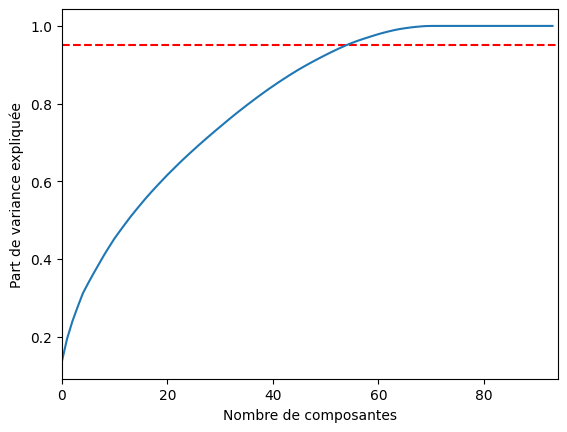

In [56]:
# Nombre de composantes pour 95% dela variance expliquée cumulée:
plt.figure()
plt.xlim(0,94)
plt.xlabel('Nombre de composantes')
plt.ylabel('Part de variance expliquée')
plt.axhline(y = 0.95, color ='r', linestyle = '--')
plt.plot(pca.explained_variance_ratio_.cumsum());

In [57]:
# On en précisant directement en PCA:
pca = PCA(0.95)
X_train_pca = pca.fit_transform(X_train)

In [58]:
X_train_pca.shape

(20569, 55)

In [59]:
pca.components_.shape

(55, 94)

In [60]:
pca.components_

array([[-0.16100865,  0.17365911,  0.14913344, ...,  0.20218722,
        -0.20218722,  0.20218722],
       [-0.0003179 , -0.17381533, -0.09641116, ...,  0.12616434,
        -0.12616434,  0.12616434],
       [ 0.0559645 ,  0.0084079 , -0.00364227, ...,  0.19727949,
        -0.19727949,  0.19727949],
       ...,
       [ 0.11080802,  0.01057713, -0.17317141, ..., -0.05240455,
         0.05240455, -0.05240455],
       [ 0.07412126, -0.08095244,  0.03774352, ...,  0.03529125,
        -0.03529125,  0.03529125],
       [-0.27800727, -0.11742335, -0.0106019 , ..., -0.01172895,
         0.01172895, -0.01172895]], shape=(55, 94))

In [61]:
feature_contribution = pca.components_.T* np.sqrt(pca.explained_variance_)

In [62]:
feature_contribution.shape

(94, 55)

In [63]:
df_feature_contribution = pd.DataFrame(data=feature_contribution, index = X_train.columns)

In [64]:
df_feature_contribution

,0,1,2,3,4,5,6,7,8,9,...,45,46,47,48,49,50,51,52,53,54
etage,-5.525755e-01,-7.225618e-04,1.102349e-01,-3.074088e-02,1.519663e-02,-3.669850e-02,-1.510382e-01,-5.116196e-02,6.008046e-02,1.181497e-01,...,-8.948384e-02,1.704994e-02,0.023952,-3.303960e-01,1.742845e-01,-3.303432e-01,1.426836e-01,8.343551e-02,5.484137e-02,-2.002125e-01
surface,5.959914e-01,-3.950702e-01,1.656130e-02,3.175748e-01,-1.647088e-01,8.681998e-02,-1.651111e-01,3.450946e-02,8.828144e-03,-2.505691e-02,...,-1.384947e-02,1.112195e-03,-0.037671,7.787265e-02,-3.343941e-02,2.757653e-02,-3.405661e-02,7.964299e-03,-5.989567e-02,-8.456477e-02
surface_terrain,5.118202e-01,-2.191359e-01,-7.174292e-03,1.218496e-01,-1.413086e-02,1.675723e-02,-2.122340e-01,3.497216e-02,-4.768682e-02,9.635400e-04,...,-9.173111e-02,-1.689268e-01,0.051860,-2.032196e-01,2.580185e-01,7.150896e-02,-2.678716e-01,-1.303935e-01,2.792594e-02,-7.635167e-03
nb_pieces,6.247306e-01,-4.019202e-01,-1.579520e-02,3.472805e-01,-1.668895e-01,6.188408e-02,-1.796133e-01,4.591156e-02,1.774676e-02,-2.465481e-02,...,-6.908270e-02,2.359420e-02,-0.030944,6.387182e-02,-3.269559e-02,5.202419e-02,-1.554462e-03,1.772170e-02,-6.555970e-02,-8.214550e-02
mensualiteFinance,-1.488376e-18,2.365744e-17,-3.280258e-16,-1.876734e-16,-3.038872e-17,-6.258036e-17,-8.122888e-17,1.199269e-16,3.981720e-17,1.534390e-16,...,-1.759321e-16,1.198383e-16,-0.000000,6.628556e-17,-5.487975e-17,-3.239618e-16,-3.082709e-16,2.680977e-16,-1.373345e-16,8.994930e-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TYP_IRIS_x_D,1.089972e-02,2.006076e-02,-5.607959e-02,1.907659e-02,2.696464e-02,-2.936398e-02,3.171731e-02,-3.373826e-02,-3.003168e-04,-2.283787e-02,...,-7.737838e-03,4.806063e-02,0.038106,3.363649e-02,-1.670085e-03,8.147438e-03,-9.447604e-03,8.846809e-03,-4.927393e-03,-2.823790e-03
TYP_IRIS_x_H,-6.944878e-01,-2.878461e-01,-3.855598e-01,3.289805e-01,-2.089866e-01,-1.499926e-01,1.658691e-01,5.447879e-02,-1.337150e-01,1.087427e-01,...,-1.889237e-03,-6.382297e-02,-0.041125,9.450348e-03,-1.448902e-02,-2.611792e-02,1.011952e-03,3.898164e-02,-2.584553e-02,8.599303e-03
TYP_IRIS_x_Z,6.938988e-01,2.867628e-01,3.885872e-01,-3.300102e-01,2.075306e-01,1.515778e-01,-1.675813e-01,-5.265723e-02,1.337311e-01,-1.075096e-01,...,2.306999e-03,6.122814e-02,0.039068,-1.126636e-02,1.457917e-02,2.567802e-02,-5.018778e-04,-3.945924e-02,2.611154e-02,-8.446840e-03
TYP_IRIS_y_H,-6.938988e-01,-2.867628e-01,-3.885872e-01,3.300102e-01,-2.075306e-01,-1.515778e-01,1.675813e-01,5.265723e-02,-1.337311e-01,1.075096e-01,...,-2.306999e-03,-6.122814e-02,-0.039068,1.126636e-02,-1.457917e-02,-2.567802e-02,5.018778e-04,3.945924e-02,-2.611154e-02,8.446840e-03


In [65]:
df_feature_contribution = df_feature_contribution.abs()

In [66]:
df_feature_contribution

,0,1,2,3,4,5,6,7,8,9,...,45,46,47,48,49,50,51,52,53,54
etage,5.525755e-01,7.225618e-04,1.102349e-01,3.074088e-02,1.519663e-02,3.669850e-02,1.510382e-01,5.116196e-02,6.008046e-02,1.181497e-01,...,8.948384e-02,1.704994e-02,0.023952,3.303960e-01,1.742845e-01,3.303432e-01,1.426836e-01,8.343551e-02,5.484137e-02,2.002125e-01
surface,5.959914e-01,3.950702e-01,1.656130e-02,3.175748e-01,1.647088e-01,8.681998e-02,1.651111e-01,3.450946e-02,8.828144e-03,2.505691e-02,...,1.384947e-02,1.112195e-03,0.037671,7.787265e-02,3.343941e-02,2.757653e-02,3.405661e-02,7.964299e-03,5.989567e-02,8.456477e-02
surface_terrain,5.118202e-01,2.191359e-01,7.174292e-03,1.218496e-01,1.413086e-02,1.675723e-02,2.122340e-01,3.497216e-02,4.768682e-02,9.635400e-04,...,9.173111e-02,1.689268e-01,0.051860,2.032196e-01,2.580185e-01,7.150896e-02,2.678716e-01,1.303935e-01,2.792594e-02,7.635167e-03
nb_pieces,6.247306e-01,4.019202e-01,1.579520e-02,3.472805e-01,1.668895e-01,6.188408e-02,1.796133e-01,4.591156e-02,1.774676e-02,2.465481e-02,...,6.908270e-02,2.359420e-02,0.030944,6.387182e-02,3.269559e-02,5.202419e-02,1.554462e-03,1.772170e-02,6.555970e-02,8.214550e-02
mensualiteFinance,1.488376e-18,2.365744e-17,3.280258e-16,1.876734e-16,3.038872e-17,6.258036e-17,8.122888e-17,1.199269e-16,3.981720e-17,1.534390e-16,...,1.759321e-16,1.198383e-16,0.000000,6.628556e-17,5.487975e-17,3.239618e-16,3.082709e-16,2.680977e-16,1.373345e-16,8.994930e-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TYP_IRIS_x_D,1.089972e-02,2.006076e-02,5.607959e-02,1.907659e-02,2.696464e-02,2.936398e-02,3.171731e-02,3.373826e-02,3.003168e-04,2.283787e-02,...,7.737838e-03,4.806063e-02,0.038106,3.363649e-02,1.670085e-03,8.147438e-03,9.447604e-03,8.846809e-03,4.927393e-03,2.823790e-03
TYP_IRIS_x_H,6.944878e-01,2.878461e-01,3.855598e-01,3.289805e-01,2.089866e-01,1.499926e-01,1.658691e-01,5.447879e-02,1.337150e-01,1.087427e-01,...,1.889237e-03,6.382297e-02,0.041125,9.450348e-03,1.448902e-02,2.611792e-02,1.011952e-03,3.898164e-02,2.584553e-02,8.599303e-03
TYP_IRIS_x_Z,6.938988e-01,2.867628e-01,3.885872e-01,3.300102e-01,2.075306e-01,1.515778e-01,1.675813e-01,5.265723e-02,1.337311e-01,1.075096e-01,...,2.306999e-03,6.122814e-02,0.039068,1.126636e-02,1.457917e-02,2.567802e-02,5.018778e-04,3.945924e-02,2.611154e-02,8.446840e-03
TYP_IRIS_y_H,6.938988e-01,2.867628e-01,3.885872e-01,3.300102e-01,2.075306e-01,1.515778e-01,1.675813e-01,5.265723e-02,1.337311e-01,1.075096e-01,...,2.306999e-03,6.122814e-02,0.039068,1.126636e-02,1.457917e-02,2.567802e-02,5.018778e-04,3.945924e-02,2.611154e-02,8.446840e-03


In [67]:
df_feature_contribution['mean_contribution'] = df_feature_contribution.mean(axis=1)

In [68]:
df_feature_contribution['mean_contribution'].sort_values(ascending=False)

dpe_B                     1.087458e-01
Latitude_scaled           1.084276e-01
ges_G                     1.075901e-01
ges_A                     1.057258e-01
dpe_G                     1.048555e-01
                              ...     
REG                       7.692062e-17
energie_inconnue          4.775794e-17
chauf_inconnu             4.045755e-17
chauffage_mode_inconnu    2.087458e-17
type_annonceur_pr         1.068918e-17
Name: mean_contribution, Length: 94, dtype: float64

In [69]:
# Pour différentes valeurs d'un seuil de contribution, on regarde combien de features on garderait

for threshold in [0.1, 0.08, 0.06, 0.04, 0.02, 0.01]:
    feature_selected = df_feature_contribution[df_feature_contribution['mean_contribution'] > threshold]
    index_selected = feature_selected.index
    print(f"seuil: {threshold}, nombre de features selectionnées: {len(index_selected)}")

seuil: 0.1, nombre de features selectionnées: 13
seuil: 0.08, nombre de features selectionnées: 48
seuil: 0.06, nombre de features selectionnées: 78
seuil: 0.04, nombre de features selectionnées: 87
seuil: 0.02, nombre de features selectionnées: 87
seuil: 0.01, nombre de features selectionnées: 87


In [70]:
feature_selected = df_feature_contribution[df_feature_contribution['mean_contribution'] > 0.06]
features_selected_pca = list(feature_selected.index)
features_selected_pca

['etage',
 'surface',
 'surface_terrain',
 'nb_pieces',
 'balcon',
 'eau',
 'bain',
 'dpeC',
 'nb_etages',
 'places_parking',
 'cave',
 'annee_construction',
 'nb_toilettes',
 'nb_logements_copro',
 'charges_copro',
 'logement_neuf',
 'IRIS',
 'prix_m2_vente',
 'Latitude_scaled',
 'Longitude_scaled',
 'prix_bien_target_encoding',
 'annee_2019',
 'annee_2020',
 'annee_2021',
 'annee_2022',
 'annee_2023',
 'expo_nord',
 'expo_sud',
 'expo_est',
 'expo_ouest',
 'expo_inconnue',
 'chauf_radiateur',
 'chauf_sol',
 'chauf_convecteur',
 'chauf_poele_bois',
 'chauf_pac',
 'chauf_clim_rev',
 'chauf_cheminee',
 'energie_gaz',
 'energie_elec',
 'energie_fioul',
 'energie_bois',
 'dpe_A',
 'dpe_B',
 'dpe_C',
 'dpe_D',
 'dpe_E',
 'dpe_F',
 'dpe_G',
 'dpe_inconnu',
 'ges_A',
 'ges_B',
 'ges_C',
 'ges_D',
 'ges_E',
 'ges_F',
 'ges_G',
 'ges_inconnu',
 'chauffage_mode_individuel',
 'chauffage_mode_collectif',
 'chauffage_mode_central',
 'typedetransaction_pi',
 'typedetransaction_v',
 'typedetransacti

## 14.3) Matthieu

### 14.3.1) LinearRegression

LinearRegression sur l'ensemble des Features

In [71]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

# Scores
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"MAE  : {mae_lr:.2f}")
print(f"RMSE : {rmse_lr:.2f}")
print(f"R2   : {r2_lr:.4f}")

MAE  : 31428.47
RMSE : 50699.14
R2   : 0.8985


Coefficients des Features

In [72]:
# Création du dictionnaire avec les coefficients absolus
columns_coef = dict(zip(X_train.columns, np.abs(lr.coef_[0]).tolist()))

# Tri par ordre décroissant des coefficients
columns_coef_trie = dict(sorted(columns_coef.items(), key=lambda item: item[1], reverse=True))

# Création du DataFrame avec l'ordre, la feature et le coefficient
df_resultats = pd.DataFrame([
    {'Ordre d\'importance': i, 'Feature': feature, 'Coefficient en valeur absolue': coef}
    for i, (feature, coef) in enumerate(columns_coef_trie.items(), start=1)
])

df_resultats.head(10)


,Ordre d'importance,Feature,Coefficient en valeur absolue
0,1,surface,101690.270683
1,2,prix_m2_vente,96291.434537
2,3,prix_bien_target_encoding,40609.028414
3,4,nb_pieces,17839.449118
4,5,surface_terrain,7787.940575
5,6,ascenseur,7657.392469
6,7,Longitude_scaled,5930.848221
7,8,IRIS,5346.676171
8,9,UU2010,5313.970229
9,10,categorie_annonceur_cm,5253.494794


In [73]:
features_selected_lr = df_resultats['Feature'].tolist()
features_selected_lr

['surface',
 'prix_m2_vente',
 'prix_bien_target_encoding',
 'nb_pieces',
 'surface_terrain',
 'ascenseur',
 'Longitude_scaled',
 'IRIS',
 'UU2010',
 'categorie_annonceur_cm',
 'logement_neuf',
 'energie_gaz',
 'energie_elec',
 'energie_fioul',
 'bain',
 'dpe_A',
 'chauf_sol',
 'chauffage_mode_collectif',
 'expo_sud',
 'charges_copro',
 'dpeC',
 'annee_construction',
 'typedebien_lite_m',
 'typedebien_a',
 'typedebien_m',
 'typedebien_lite_a',
 'chauffage_mode_individuel',
 'dpe_inconnu',
 'expo_inconnue',
 'ges_inconnu',
 'categorie_annonceur_ca',
 'eau',
 'categorie_annonceur_a',
 'categorie_annonceur_b',
 'nb_toilettes',
 'dpe_C',
 'etage',
 'ges_A',
 'categorie_annonceur_network',
 'chauf_pac',
 'annonce_exclusive_Non',
 'dpe_F',
 'energie_bois',
 'ges_E',
 'typedetransaction_v',
 'cave',
 'typedetransaction_vp',
 'dpe_D',
 'categorie_annonceur_m',
 'annonce_exclusive_Oui',
 'Latitude_scaled',
 'nb_logements_copro',
 'ges_C',
 'dpe_G',
 'dpe_E',
 'nb_etages',
 'annee_2019',
 'ges_B

<Axes: >

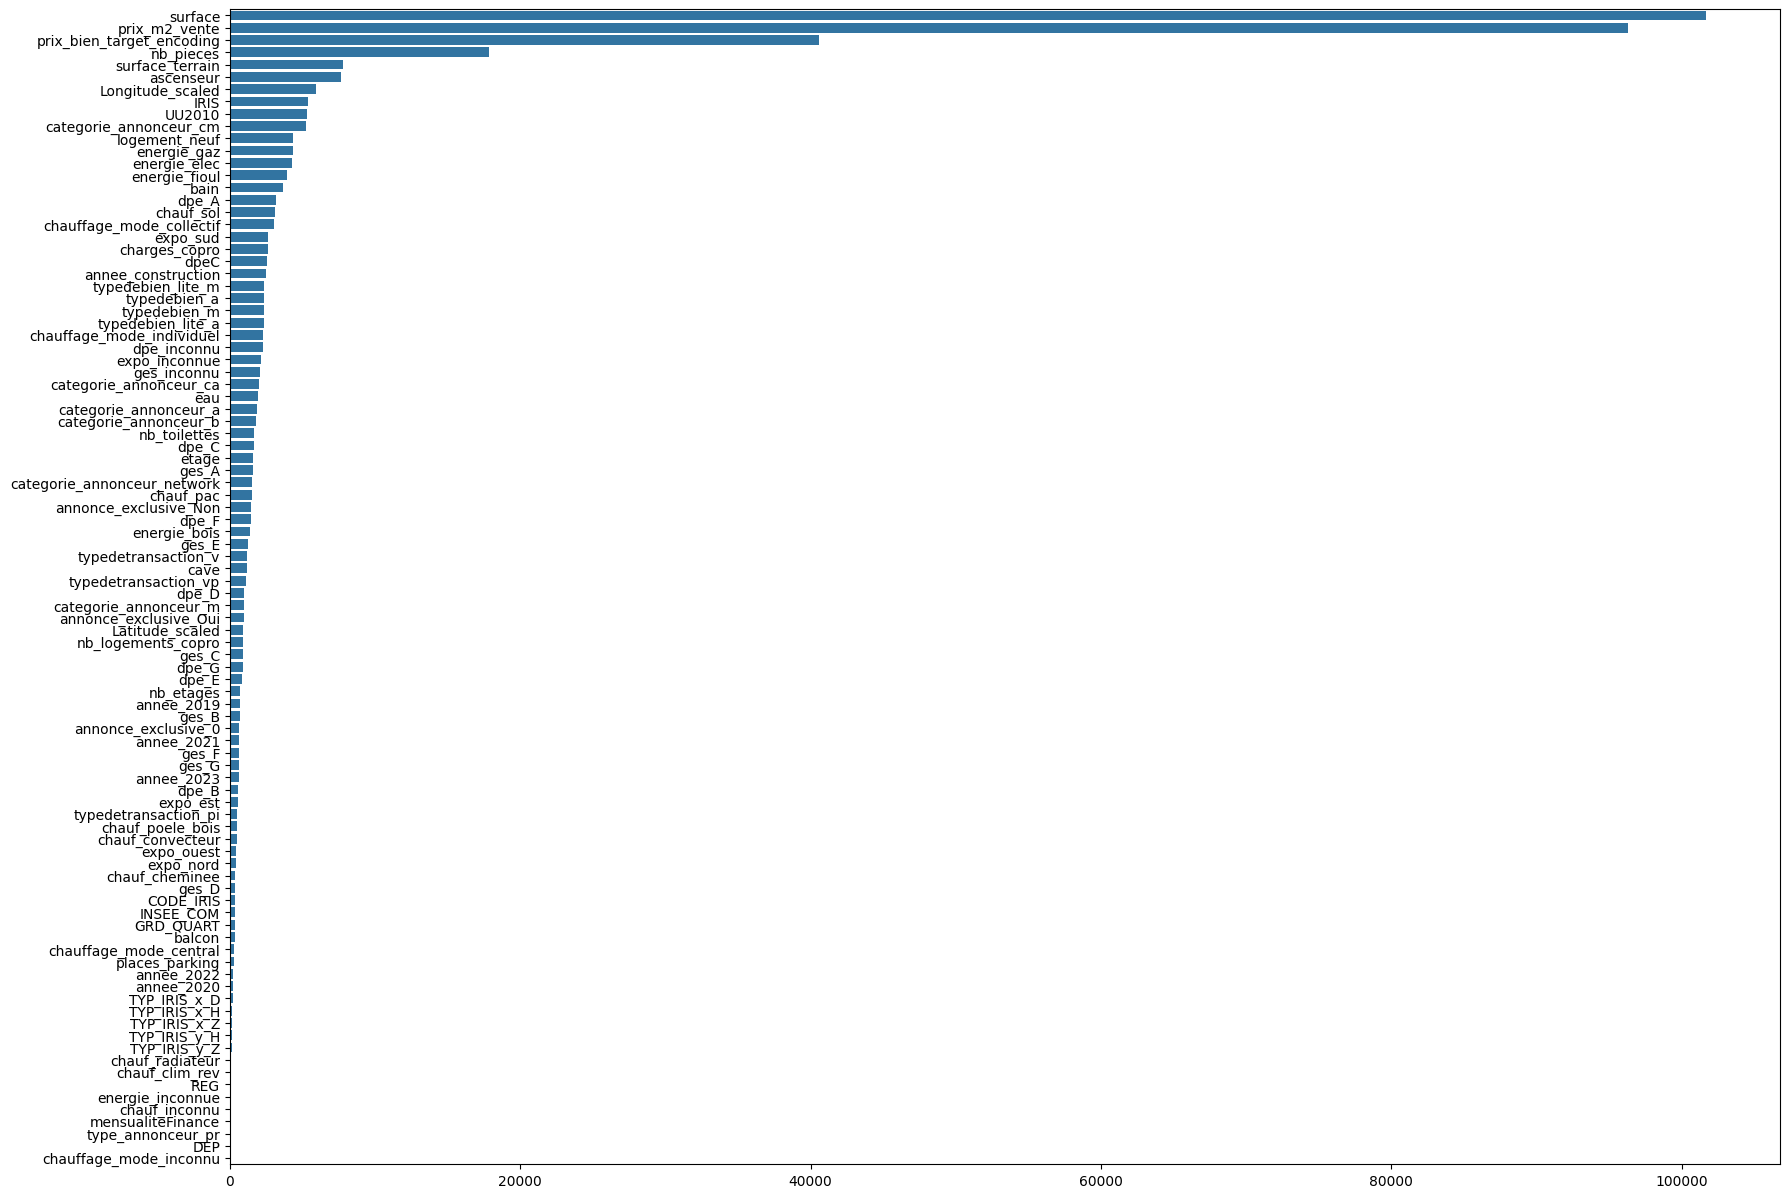

In [74]:
fig, ax = plt.subplots(figsize = (20,15))
sns.barplot(x=columns_coef_trie.values(), y=columns_coef_trie.keys())

LinearRegression en ne gardant que les 10 plus gros coefficient

In [75]:
lr_10 = LinearRegression()
lr_10.fit(X_train[df_resultats.Feature[:10].values.tolist()], y_train)

y_pred_lr_10 = lr_10.predict(X_test[df_resultats.Feature[:10].values.tolist()])

# Scores
mae_lr_10 = mean_absolute_error(y_test, y_pred_lr_10)
rmse_lr_10 = np.sqrt(mean_squared_error(y_test, y_pred_lr_10))
r2_lr_10 = r2_score(y_test, y_pred_lr_10)

print(f"MAE  : {mae_lr_10:.2f}")
print(f"RMSE : {rmse_lr_10:.2f}")
print(f"R2   : {r2_lr_10:.4f}")


MAE  : 32778.69
RMSE : 52717.45
R2   : 0.8903


Comparaison LinearRegression avec 94 Features et 10 Features

In [76]:
print("### Linear Regresion avec 94 Features ###")
print(f"MAE  : {mae_lr:.2f}")
print(f"RMSE : {rmse_lr:.2f}")
print(f"R2   : {r2_lr:.4f}")

print("\n### Linear Regresion avec 10 Features ###")
print(f"MAE  : {mae_lr_10:.2f}")
print(f"RMSE : {rmse_lr_10:.2f}")
print(f"R2   : {r2_lr_10:.4f}")

### Linear Regresion avec 94 Features ###
MAE  : 31428.47
RMSE : 50699.14
R2   : 0.8985

### Linear Regresion avec 10 Features ###
MAE  : 32778.69
RMSE : 52717.45
R2   : 0.8903


### 14.3.2) LinearRegression + Backward Elimination

SequentialFeatureSelector (backward)

Features retenues : Index(['etage', 'surface', 'surface_terrain', 'nb_pieces', 'eau', 'bain',
       'dpeC', 'cave', 'annee_construction', 'nb_toilettes', 'ascenseur',
       'charges_copro', 'logement_neuf', 'IRIS', 'GRD_QUART', 'UU2010',
       'prix_m2_vente', 'Latitude_scaled', 'Longitude_scaled',
       'prix_bien_target_encoding', 'annee_2023', 'expo_sud', 'expo_est',
       'expo_inconnue', 'chauf_sol', 'chauf_pac', 'energie_gaz', 'dpe_B',
       'dpe_C', 'dpe_D', 'dpe_E', 'dpe_F', 'dpe_G', 'dpe_inconnu', 'ges_B',
       'ges_C', 'ges_D', 'ges_G', 'ges_inconnu', 'chauffage_mode_collectif',
       'typedetransaction_pi', 'typedetransaction_vp', 'annonce_exclusive_Non',
       'categorie_annonceur_b', 'categorie_annonceur_cm',
       'categorie_annonceur_network', 'typedebien_lite_a'],
      dtype='object')
MAE  : 31497.50
RMSE : 50755.38
R2   : 0.8983


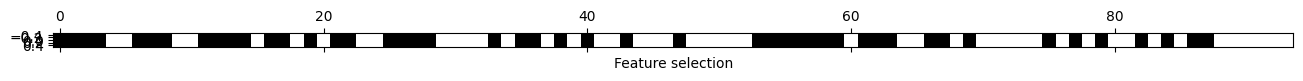

In [77]:
lr_backward_auto = LinearRegression()

# Backward Selection (recul)
sfs = SequentialFeatureSelector(
    lr_backward_auto,
    n_features_to_select='auto',
    direction="backward",
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring="neg_mean_squared_error"
)

sfs.fit(X_train, y_train.values.ravel())

# Colonnes retenues
mask = sfs.get_support()
selected_features = X_train.columns[mask]

plt.matshow(mask.reshape(1,-1), cmap = 'gray_r')
plt.xlabel('Feature selection');

print("Features retenues :", selected_features)

# Modèle final sur features retenues
lr_backward_auto.fit(X_train[selected_features], y_train)
y_pred_lr_backward_auto = lr_backward_auto.predict(X_test[selected_features])

mae_lr_backward_auto = mean_absolute_error(y_test, y_pred_lr_backward_auto)
rmse_lr_backward_auto = np.sqrt(mean_squared_error(y_test, y_pred_lr_backward_auto))
r2_lr_backward_auto = r2_score(y_test, y_pred_lr_backward_auto)

print(f"MAE  : {mae_lr_backward_auto:.2f}")
print(f"RMSE : {rmse_lr_backward_auto:.2f}")
print(f"R2   : {r2_lr_backward_auto:.4f}")


In [78]:
features_selected_sfs = selected_features
len(features_selected_sfs)

47

In [79]:
print("### Linear Regresion avec 94 Features ###")
print(f"MAE  : {mae_lr:.2f}")
print(f"RMSE : {rmse_lr:.2f}")
print(f"R2   : {r2_lr:.4f}")

print("\n### Linear Regresion avec 10 Features ###")
print(f"MAE  : {mae_lr_10:.2f}")
print(f"RMSE : {rmse_lr_10:.2f}")
print(f"R2   : {r2_lr_10:.4f}")

print("\n### Linear Regresion avec Backward Elimination n_features_to_select='auto' (47 Features) ###")
print(f"MAE  : {mae_lr_backward_auto:.2f}")
print(f"RMSE : {rmse_lr_backward_auto:.2f}")
print(f"R2   : {r2_lr_backward_auto:.4f}")

### Linear Regresion avec 94 Features ###
MAE  : 31428.47
RMSE : 50699.14
R2   : 0.8985

### Linear Regresion avec 10 Features ###
MAE  : 32778.69
RMSE : 52717.45
R2   : 0.8903

### Linear Regresion avec Backward Elimination n_features_to_select='auto' (47 Features) ###
MAE  : 31497.50
RMSE : 50755.38
R2   : 0.8983


### 14.4.3) LinearRegression + SelectKBest

Features retenues : Index(['etage', 'surface', 'surface_terrain', 'nb_pieces', 'balcon', 'eau',
       'bain', 'dpeC', 'nb_etages', 'places_parking', 'nb_toilettes',
       'ascenseur', 'nb_logements_copro', 'charges_copro', 'logement_neuf',
       'IRIS', 'UU2010', 'prix_m2_vente', 'Longitude_scaled',
       'prix_bien_target_encoding', 'annee_2020', 'annee_2022', 'annee_2023',
       'energie_gaz', 'energie_elec', 'energie_fioul', 'dpe_A', 'dpe_B',
       'dpe_E', 'ges_A', 'chauffage_mode_individuel',
       'chauffage_mode_collectif', 'typedebien_a', 'typedebien_m',
       'typedetransaction_v', 'typedetransaction_vp', 'annonce_exclusive_0',
       'annonce_exclusive_Oui', 'categorie_annonceur_a',
       'categorie_annonceur_cm', 'typedebien_lite_a', 'typedebien_lite_m',
       'TYP_IRIS_x_H', 'TYP_IRIS_x_Z', 'TYP_IRIS_y_H', 'TYP_IRIS_y_Z'],
      dtype='object')
MAE  : 31901.39
RMSE : 51343.13
R2   : 0.8959


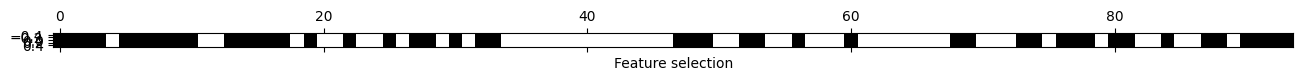

In [80]:
# Choix de K
k = 46

# SelectKBest
selector = SelectKBest(score_func=f_regression, k=k)
selector.fit(X_train, y_train.values.ravel())

# Colonnes retenues
mask = selector.get_support()
kbest_features = X_train.columns[mask]

plt.matshow(mask.reshape(1,-1), cmap = 'gray_r')
plt.xlabel('Feature selection');

print("Features retenues :", kbest_features)

# Modèle final
lr_kbest = LinearRegression()
lr_kbest.fit(X_train[kbest_features], y_train)

y_pred_kbest = lr_kbest.predict(X_test[kbest_features])

mae_kbest = mean_absolute_error(y_test, y_pred_kbest)
rmse_kbest = np.sqrt(mean_squared_error(y_test, y_pred_kbest))
r2_kbest = r2_score(y_test, y_pred_kbest)

print(f"MAE  : {mae_kbest:.2f}")
print(f"RMSE : {rmse_kbest:.2f}")
print(f"R2   : {r2_kbest:.4f}")


In [81]:
print("### Linear Regresion avec 94 Features ###")
print(f"MAE  : {mae_lr:.2f}")
print(f"RMSE : {rmse_lr:.2f}")
print(f"R2   : {r2_lr:.4f}")

print("\n### Linear Regresion avec 10 Features ###")
print(f"MAE  : {mae_lr_10:.2f}")
print(f"RMSE : {rmse_lr_10:.2f}")
print(f"R2   : {r2_lr_10:.4f}")

print("\n### Linear Regresion avec Backward Elimination n_features_to_select='auto' (47 Features) ###")
print(f"MAE  : {mae_lr_backward_auto:.2f}")
print(f"RMSE : {rmse_lr_backward_auto:.2f}")
print(f"R2   : {r2_lr_backward_auto:.4f}")

print("\n### Linear Regresion avec SelectKBest (k=46 Features) ###")
print(f"MAE  : {mae_kbest:.2f}")
print(f"RMSE : {rmse_kbest:.2f}")
print(f"R2   : {r2_kbest:.4f}")

### Linear Regresion avec 94 Features ###
MAE  : 31428.47
RMSE : 50699.14
R2   : 0.8985

### Linear Regresion avec 10 Features ###
MAE  : 32778.69
RMSE : 52717.45
R2   : 0.8903

### Linear Regresion avec Backward Elimination n_features_to_select='auto' (47 Features) ###
MAE  : 31497.50
RMSE : 50755.38
R2   : 0.8983

### Linear Regresion avec SelectKBest (k=46 Features) ###
MAE  : 31901.39
RMSE : 51343.13
R2   : 0.8959


In [82]:
features_selected_kbest = kbest_features
len(features_selected_kbest)

46

In [83]:
selected_dict = { 'pca': features_selected_pca,
                  'lr': features_selected_lr,
                  'sfs': features_selected_sfs,
                  'kbest': features_selected_kbest}

In [84]:
joblib.dump(selected_dict, "selected_dict.joblib")

['selected_dict.joblib']

## 14.4) Intersection

In [85]:
#si l'on regarde l'intersection entre les features sélectionnées par la PCA et les features sélectionnées par la lr:
selected = set(selected_dict['pca'][:46]).intersection(set(selected_dict['lr'][:46])).intersection(set(selected_dict['sfs'])).intersection(set(selected_dict['kbest']))
selected = list(selected)
selected

['IRIS',
 'surface',
 'Longitude_scaled',
 'etage',
 'prix_m2_vente',
 'surface_terrain',
 'logement_neuf',
 'eau',
 'energie_gaz',
 'nb_pieces',
 'bain',
 'nb_toilettes',
 'dpeC',
 'charges_copro',
 'prix_bien_target_encoding']

In [86]:
len(selected)

15

In [87]:
# Si on essaie une régression avec ces 15 features:
lr_15 = LinearRegression()
lr_15.fit(X_train[selected], y_train)

# Prédictions
y_pred_15 = lr_15.predict(X_test[selected])

# Scores
mae_15 = mean_absolute_error(y_test, y_pred_15)
rmse_15 = np.sqrt(mean_squared_error(y_test, y_pred_15))
r2_15 = r2_score(y_test, y_pred_15)

print(f"MAE  : {mae_15:.2f}")
print(f"RMSE : {rmse_15:.2f}")
print(f"R2   : {r2_15:.4f}")


MAE  : 33038.27
RMSE : 53103.04
R2   : 0.8887


In [88]:
print("### Linear Regresion avec 94 Features ###")
print(f"MAE  : {mae_lr:.2f}")
print(f"RMSE : {rmse_lr:.2f}")
print(f"R2   : {r2_lr:.4f}")

print("\n### Linear Regresion avec 10 Features ###")
print(f"MAE  : {mae_lr_10:.2f}")
print(f"RMSE : {rmse_lr_10:.2f}")
print(f"R2   : {r2_lr_10:.4f}")

print("\n### Linear Regresion avec Backward Elimination n_features_to_select='auto' (47 Features) ###")
print(f"MAE  : {mae_lr_backward_auto:.2f}")
print(f"RMSE : {rmse_lr_backward_auto:.2f}")
print(f"R2   : {r2_lr_backward_auto:.4f}")

print("\n### Linear Regresion avec SelectKBest (k=46 Features) ###")
print(f"MAE  : {mae_kbest:.2f}")
print(f"RMSE : {rmse_kbest:.2f}")
print(f"R2   : {r2_kbest:.4f}")

print("\n### Linear Regresion avec 15 Features (intersection des méthodes précédentes) ###")
print(f"MAE  : {mae_15:.2f}")
print(f"RMSE : {rmse_15:.2f}")
print(f"R2   : {r2_15:.4f}")

### Linear Regresion avec 94 Features ###
MAE  : 31428.47
RMSE : 50699.14
R2   : 0.8985

### Linear Regresion avec 10 Features ###
MAE  : 32778.69
RMSE : 52717.45
R2   : 0.8903

### Linear Regresion avec Backward Elimination n_features_to_select='auto' (47 Features) ###
MAE  : 31497.50
RMSE : 50755.38
R2   : 0.8983

### Linear Regresion avec SelectKBest (k=46 Features) ###
MAE  : 31901.39
RMSE : 51343.13
R2   : 0.8959

### Linear Regresion avec 15 Features (intersection des méthodes précédentes) ###
MAE  : 33038.27
RMSE : 53103.04
R2   : 0.8887


On est un peu moins bien que pour uniquement les 15 features mais on est sur un seul type de modèle (régression linéaire). On verra par la suite avec les autres modèles et en optimisant ce que l'on obtiendra...

In [89]:
y_pred = pd.DataFrame(data = y_pred_15, index=y_test.index)

In [90]:
y_pred = y_pred.rename(columns={0: "prix_bien"})

In [91]:
diff = y_test - y_pred

In [92]:
y_test

,prix_bien
idannonce,
guy-hoquet-immo-facile-5974993,115400
ag680297-277810664,106500
orpi-1-054041E1OWKF,118250
guy-hoquet-immo-facile-6243822,76000
ag440414-293552741,390000
...,...
immo-facile-35871425,100000
ag680254-273036872,210000
ag681158-373018354,72000


In [93]:
y_pred

,prix_bien
idannonce,
guy-hoquet-immo-facile-5974993,171031.329178
ag680297-277810664,79130.964170
orpi-1-054041E1OWKF,89105.674323
guy-hoquet-immo-facile-6243822,45245.743635
ag440414-293552741,354738.620538
...,...
immo-facile-35871425,84732.066144
ag680254-273036872,232467.433558
ag681158-373018354,41700.313097


In [94]:
y_test.loc['ag681120-337284537', 'prix_bien']

np.int64(2300000)

In [95]:
diff

,prix_bien
idannonce,
guy-hoquet-immo-facile-5974993,-55631.329178
ag680297-277810664,27369.035830
orpi-1-054041E1OWKF,29144.325677
guy-hoquet-immo-facile-6243822,30754.256365
ag440414-293552741,35261.379462
...,...
immo-facile-35871425,15267.933856
ag680254-273036872,-22467.433558
ag681158-373018354,30299.686903


In [96]:
diff.idxmax()

prix_bien    ag681120-337284537
dtype: object

In [97]:
diff.loc['ag681120-337284537']

prix_bien    1.020508e+06
Name: ag681120-337284537, dtype: float64

In [98]:
print(f"prediction: {int(y_pred.loc['ag681120-337284537', 'prix_bien'])}, prix réel: {y_test.loc['ag681120-337284537', 'prix_bien']}")

prediction: 1279491, prix réel: 2300000


In [99]:
df_ventes.loc['ag681120-337284537']

type_annonceur                    pr
typedebien                         m
typedetransaction                  v
etage                              0
surface                          354
surface_terrain               1300.0
nb_pieces                          8
prix_bien                    2300000
mensualiteFinance                  0
balcon                             0
eau                                0
bain                               0
dpeL                               B
dpeC                            89.0
mapCoordonneesLatitude      47.49404
mapCoordonneesLongitude      7.48269
annonce_exclusive                Non
nb_etages                       <NA>
places_parking                  <NA>
cave                            <NA>
exposition                         0
ges_class                          B
annee_construction              <NA>
nb_toilettes                    <NA>
ascenseur                       <NA>
nb_logements_copro              <NA>
charges_copro                    NaN
c

In [100]:
diff.to_csv("diff.csv", index=True)

# 15) DecisionTreeRegressor

In [101]:
tree = DecisionTreeRegressor()

tree.fit(X_train, y_train)

tree_pred = tree.predict(X_test)
tree_pred = pd.DataFrame(tree_pred, index=y_test.index, columns=['prix_bien'])

mae_tree = mean_absolute_error(y_test, tree_pred)
rmse_tree = np.sqrt(mean_squared_error(y_test, tree_pred))
r2_tree = r2_score(y_test, tree_pred)

print(f"MAE  : {mae_tree:.2f}")
print(f"RMSE : {rmse_tree:.2f}")
print(f"R2   : {r2_tree:.4f}")

MAE  : 8160.15
RMSE : 29422.42
R2   : 0.9658


In [102]:
print("### Linear Regresion avec 94 Features ###")
print(f"MAE  : {mae_lr:.2f}")
print(f"RMSE : {rmse_lr:.2f}")
print(f"R2   : {r2_lr:.4f}")

print("\n### Linear Regresion avec 10 Features ###")
print(f"MAE  : {mae_lr_10:.2f}")
print(f"RMSE : {rmse_lr_10:.2f}")
print(f"R2   : {r2_lr_10:.4f}")

print("\n### Linear Regresion avec Backward Elimination n_features_to_select='auto' (47 Features) ###")
print(f"MAE  : {mae_lr_backward_auto:.2f}")
print(f"RMSE : {rmse_lr_backward_auto:.2f}")
print(f"R2   : {r2_lr_backward_auto:.4f}")

print("\n### Linear Regresion avec SelectKBest (k=46 Features) ###")
print(f"MAE  : {mae_kbest:.2f}")
print(f"RMSE : {rmse_kbest:.2f}")
print(f"R2   : {r2_kbest:.4f}")

print("\n### DecisionTreeRegressor avec 94 Features ###")
print(f"MAE  : {mae_tree:.2f}")
print(f"RMSE : {rmse_tree:.2f}")
print(f"R2   : {r2_tree:.4f}")

### Linear Regresion avec 94 Features ###
MAE  : 31428.47
RMSE : 50699.14
R2   : 0.8985

### Linear Regresion avec 10 Features ###
MAE  : 32778.69
RMSE : 52717.45
R2   : 0.8903

### Linear Regresion avec Backward Elimination n_features_to_select='auto' (47 Features) ###
MAE  : 31497.50
RMSE : 50755.38
R2   : 0.8983

### Linear Regresion avec SelectKBest (k=46 Features) ###
MAE  : 31901.39
RMSE : 51343.13
R2   : 0.8959

### DecisionTreeRegressor avec 94 Features ###
MAE  : 8160.15
RMSE : 29422.42
R2   : 0.9658


## 15.1) Feature importance

In [103]:
importance = tree.feature_importances_
feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
display(importance_df)


,Feature,Importance
28,prix_bien_target_encoding,0.535611
25,prix_m2_vente,0.247190
1,surface,0.211206
5,balcon,0.000926
2,surface_terrain,0.000734
...,...,...
45,chauf_cheminee,0.000000
75,typedetransaction_pi,0.000000
70,chauffage_mode_central,0.000000
71,chauffage_mode_inconnu,0.000000


In [104]:
tree_feature_importances = DecisionTreeRegressor()

tree_feature_importances.fit(X_train[['prix_bien_target_encoding', 'prix_m2_vente', 'surface']], y_train)

tree_feature_importances_pred = tree_feature_importances.predict(X_test[['prix_bien_target_encoding', 'prix_m2_vente', 'surface']])
tree_feature_importances_pred = pd.DataFrame(tree_feature_importances_pred, index=y_test.index, columns=['prix_bien'])

mae_feature_importances = mean_absolute_error(y_test, tree_feature_importances_pred)
rmse_feature_importances = np.sqrt(mean_squared_error(y_test, tree_feature_importances_pred))
r2_feature_importances = r2_score(y_test, tree_feature_importances_pred)

print(f"MAE  : {mae_feature_importances:.2f}")
print(f"RMSE : {rmse_feature_importances:.2f}")
print(f"R2   : {r2_feature_importances:.4f}")

MAE  : 5829.27
RMSE : 22832.21
R2   : 0.9794


In [105]:
print("### Linear Regresion avec 94 Features ###")
print(f"MAE  : {mae_lr:.2f}")
print(f"RMSE : {rmse_lr:.2f}")
print(f"R2   : {r2_lr:.4f}")

print("\n### Linear Regresion avec 10 Features ###")
print(f"MAE  : {mae_lr_10:.2f}")
print(f"RMSE : {rmse_lr_10:.2f}")
print(f"R2   : {r2_lr_10:.4f}")

print("\n### Linear Regresion avec Backward Elimination n_features_to_select='auto' (47 Features) ###")
print(f"MAE  : {mae_lr_backward_auto:.2f}")
print(f"RMSE : {rmse_lr_backward_auto:.2f}")
print(f"R2   : {r2_lr_backward_auto:.4f}")

print("\n### Linear Regresion avec SelectKBest (k=46 Features) ###")
print(f"MAE  : {mae_kbest:.2f}")
print(f"RMSE : {rmse_kbest:.2f}")
print(f"R2   : {r2_kbest:.4f}")

print("\n### DecisionTreeRegressor avec 94 Features ###")
print(f"MAE  : {mae_tree:.2f}")
print(f"RMSE : {rmse_tree:.2f}")
print(f"R2   : {r2_tree:.4f}")

print("\n### DecisionTreeRegressor avec les 3 Features ayant une importance significative ###")
print(f"MAE  : {mae_feature_importances:.2f}")
print(f"RMSE : {rmse_feature_importances:.2f}")
print(f"R2   : {r2_feature_importances:.4f}")

### Linear Regresion avec 94 Features ###
MAE  : 31428.47
RMSE : 50699.14
R2   : 0.8985

### Linear Regresion avec 10 Features ###
MAE  : 32778.69
RMSE : 52717.45
R2   : 0.8903

### Linear Regresion avec Backward Elimination n_features_to_select='auto' (47 Features) ###
MAE  : 31497.50
RMSE : 50755.38
R2   : 0.8983

### Linear Regresion avec SelectKBest (k=46 Features) ###
MAE  : 31901.39
RMSE : 51343.13
R2   : 0.8959

### DecisionTreeRegressor avec 94 Features ###
MAE  : 8160.15
RMSE : 29422.42
R2   : 0.9658

### DecisionTreeRegressor avec les 3 Features ayant une importance significative ###
MAE  : 5829.27
RMSE : 22832.21
R2   : 0.9794


In [106]:
importance = tree_feature_importances.feature_importances_
feature_names = ['prix_bien_target_encoding', 'prix_m2_vente', 'surface']
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
display(importance_df)


,Feature,Importance
0,prix_bien_target_encoding,0.536511
1,prix_m2_vente,0.249136
2,surface,0.214352


In [107]:
# Création d'un dictionnaire avec les données
data = {
    "Modèle": [
        "Linear Regression (94 features)",
        "Linear Regression (10 features)",
        "Linear Regression (backward elimination, auto)",
        "Linear Regression (SelectKBest, k=46)",
        "DecisionTreeRegressor (94 features)",
        "DecisionTreeRegressor (3 features)"
    ],
    "MAE": [
        mae_lr,
        mae_lr_10,
        mae_lr_backward_auto,
        mae_kbest,
        mae_tree,
        mae_feature_importances
    ],
    "RMSE": [
        rmse_lr,
        rmse_lr_10,
        rmse_lr_backward_auto,
        rmse_kbest,
        rmse_tree,
        rmse_feature_importances
    ],
    "R2": [
        r2_lr,
        r2_lr_10,
        r2_lr_backward_auto,
        r2_kbest,
        r2_tree,
        r2_feature_importances
    ]
}

# Conversion en DataFrame
results_df = pd.DataFrame(data)

# Affichage du DataFrame
results_df

,Modèle,MAE,RMSE,R2
0,Linear Regression (94 features),31428.468446,50699.135680,0.898518
1,Linear Regression (10 features),32778.685426,52717.446296,0.890277
2,"Linear Regression (backward elimination, auto)",31497.496354,50755.380841,0.898292
3,"Linear Regression (SelectKBest, k=46)",31901.385458,51343.128335,0.895923
4,DecisionTreeRegressor (94 features),8160.152721,29422.419071,0.965822
5,DecisionTreeRegressor (3 features),5829.272089,22832.208693,0.979418


# 16) Focus sur les 'mauvaises' prédictions avec DecisionTreeRegressor

In [108]:
tree_diff = y_test - tree_feature_importances_pred

In [109]:
df_tree_diff = pd.merge(tree_diff.sort_values(by='prix_bien', ascending=False), df_ventes, how='left', left_index=True, right_index=True).rename(columns={"prix_bien_x": "delta_prediction"})
df_tree_diff.shape

(5127, 49)

## 16.1) Variables catégorielles

In [110]:
df_tree_diff_mauvaises_pred = df_tree_diff[np.abs(df_tree_diff['delta_prediction']) > 10000]
df_tree_diff_mauvaises_pred.shape

(540, 49)



#### Variable  type_annonceur  ####
|delta_prediction| < 10000
type_annonceur
pr    4587
Name: count, dtype: int64

delta_prediction > 10000
type_annonceur
pr    288
Name: count, dtype: int64

delta_prediction < -10000
type_annonceur
pr    252
Name: count, dtype: int64


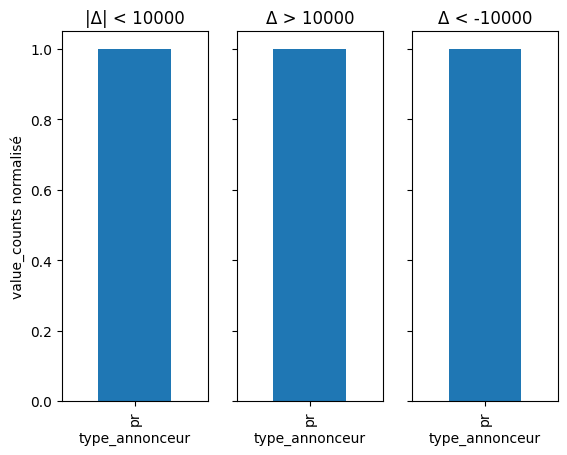



#### Variable  typedebien  ####
|delta_prediction| < 10000
typedebien
a    2388
m    2199
Name: count, dtype: int64

delta_prediction > 10000
typedebien
m    229
a     59
Name: count, dtype: int64

delta_prediction < -10000
typedebien
m    197
a     55
Name: count, dtype: int64


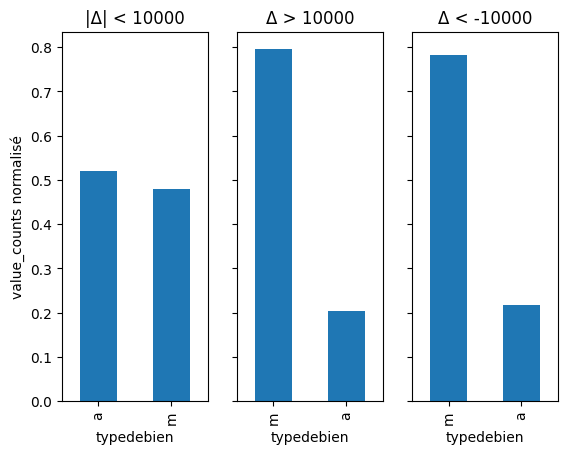



#### Variable  typedetransaction  ####
|delta_prediction| < 10000
typedetransaction
v     4553
vp      34
Name: count, dtype: int64

delta_prediction > 10000
typedetransaction
v     276
vp     12
Name: count, dtype: int64

delta_prediction < -10000
typedetransaction
v     246
vp      6
Name: count, dtype: int64


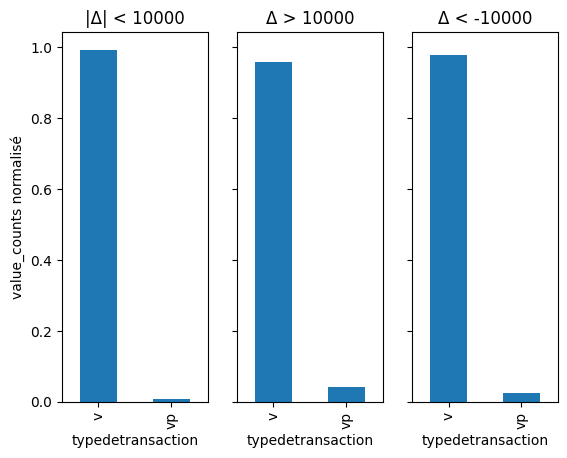



#### Variable  dpeL  ####
|delta_prediction| < 10000
dpeL
D     972
0     820
E     669
C     663
NS    390
B     282
VI    279
F     258
A     175
G      79
Name: count, dtype: int64

delta_prediction > 10000
dpeL
D     71
C     52
E     43
0     30
B     26
VI    18
A     18
F     13
NS    10
G      7
Name: count, dtype: int64

delta_prediction < -10000
dpeL
D     52
0     37
E     33
C     33
A     25
F     23
NS    16
VI    13
G     10
B     10
Name: count, dtype: int64


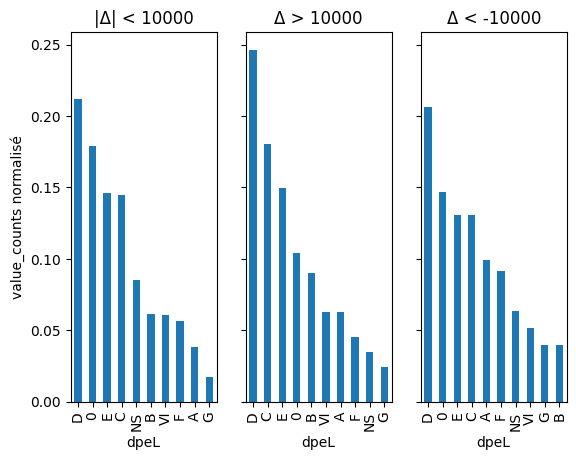



#### Variable  annonce_exclusive  ####
|delta_prediction| < 10000
annonce_exclusive
Oui    2002
Non    1847
0       738
Name: count, dtype: int64

delta_prediction > 10000
annonce_exclusive
Oui    137
Non    115
0       36
Name: count, dtype: int64

delta_prediction < -10000
annonce_exclusive
Oui    119
Non     92
0       41
Name: count, dtype: int64


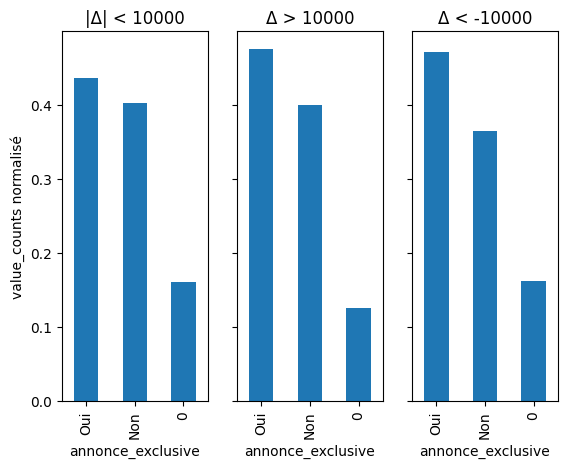



#### Variable  exposition  ####
|delta_prediction| < 10000
exposition
0                       3534
Sud                      369
Est                      113
Sud-Ouest                 93
Ouest                     92
Nord-Ouest                83
Sud-Est                   74
Est-Ouest                 60
Sud-Est-Ouest             33
sud-ouest                 32
Nord-Sud                  29
Nord                      24
sud-est                   15
Nord-Est                   9
traversant                 4
Nord Sud Est Ouest         4
nord,est                   3
Nord Est Ouest             3
Nord Sud Ouest             3
nord-est / sud-ouest       2
Nord Sud Est               2
Nord-ouest                 1
sud,ouest                  1
sud ouest                  1
nord-ouest / sud-est       1
traversant nord-sud        1
nord,ouest                 1
Name: count, dtype: int64

delta_prediction > 10000
exposition
0                223
Sud               24
Sud-Ouest         11
Sud-Est-Ouest      

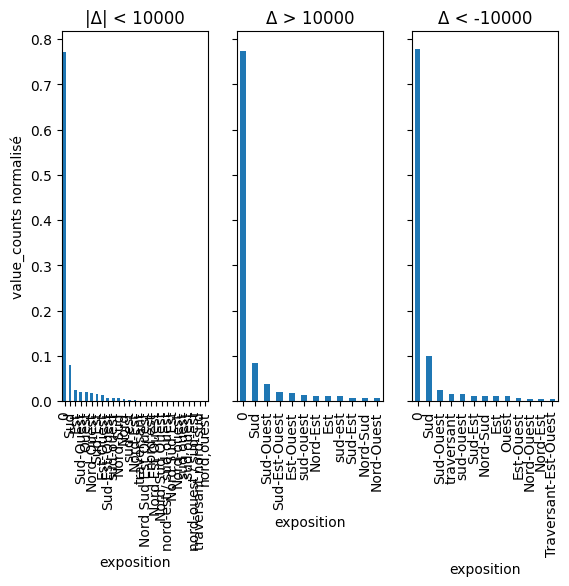



#### Variable  ges_class  ####
|delta_prediction| < 10000
ges_class
D     660
E     544
C     537
B     444
A     316
F     274
VI    242
G     164
NS    112
Name: count, dtype: int64

delta_prediction > 10000
ges_class
C     43
E     41
D     39
B     30
A     30
F     22
VI    17
G      9
NS     4
Name: count, dtype: int64

delta_prediction < -10000
ges_class
D     41
E     30
C     29
A     23
B     19
F     15
G     12
VI     9
NS     9
Name: count, dtype: int64


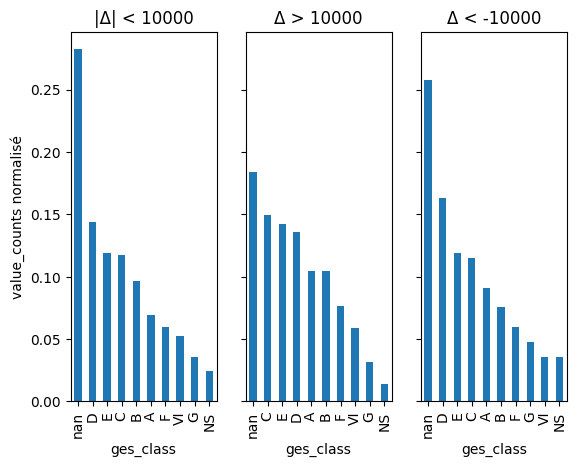



#### Variable  chauffage_energie  ####
|delta_prediction| < 10000
chauffage_energie
Gaz                 1361
Électrique           437
Fioul                322
Bois                  13
Électrique, Bois       3
Name: count, dtype: int64

delta_prediction > 10000
chauffage_energie
Gaz           68
Fioul         35
Électrique    17
Gaz, Bois      2
Bois           1
Name: count, dtype: int64

delta_prediction < -10000
chauffage_energie
Gaz                47
Électrique         27
Fioul              23
Bois                2
Gaz, Électrique     1
Name: count, dtype: int64


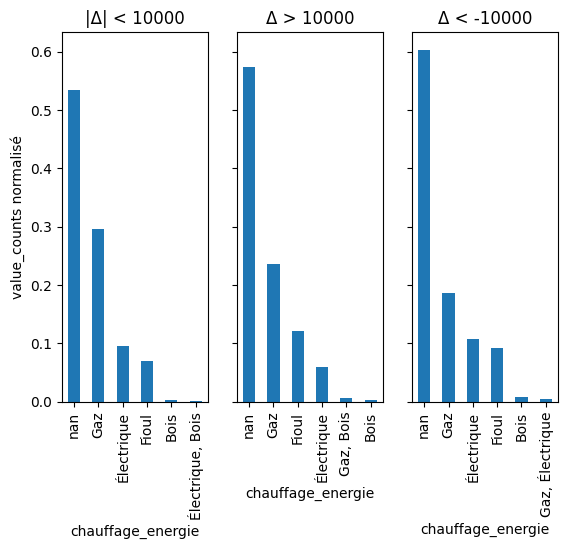



#### Variable  chauffage_systeme  ####
|delta_prediction| < 10000
chauffage_systeme
Radiateur                     1074
Sol                            173
Convecteur                      14
Pompe à chaleur, Sol            10
Poêle à Bois                     8
Pompe à chaleur                  4
Climatisation révérsible         3
Pompe à chaleur, Radiateur       3
Sol, Radiateur                   1
Name: count, dtype: int64

delta_prediction > 10000
chauffage_systeme
Radiateur          63
Sol                13
Poêle à Bois        3
Pompe à chaleur     2
Name: count, dtype: int64

delta_prediction < -10000
chauffage_systeme
Radiateur          58
Sol                13
Convecteur          1
Sol, Cheminée       1
Pompe à chaleur     1
Name: count, dtype: int64


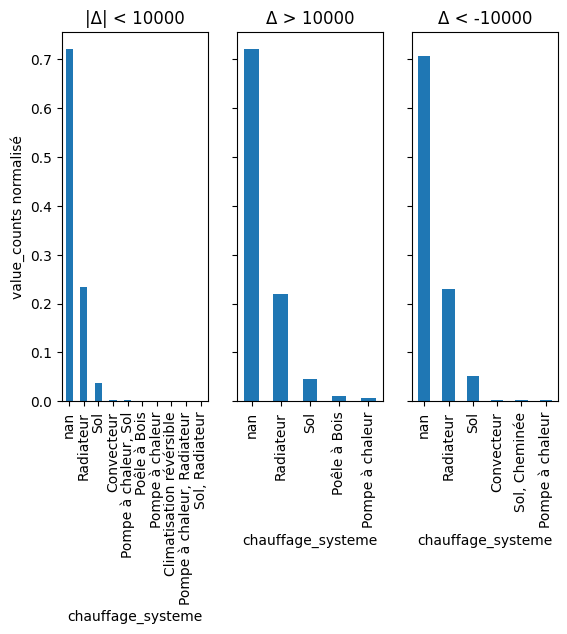



#### Variable  chauffage_mode  ####
|delta_prediction| < 10000
chauffage_mode
Individuel               1955
Collectif                 377
Collectif, Individuel      18
Individuel, Central         3
Collectif, Central          2
Central                     2
Name: count, dtype: int64

delta_prediction > 10000
chauffage_mode
Individuel               127
Collectif                  8
Collectif, Individuel      1
Name: count, dtype: int64

delta_prediction < -10000
chauffage_mode
Individuel    105
Collectif      17
Central         1
Name: count, dtype: int64


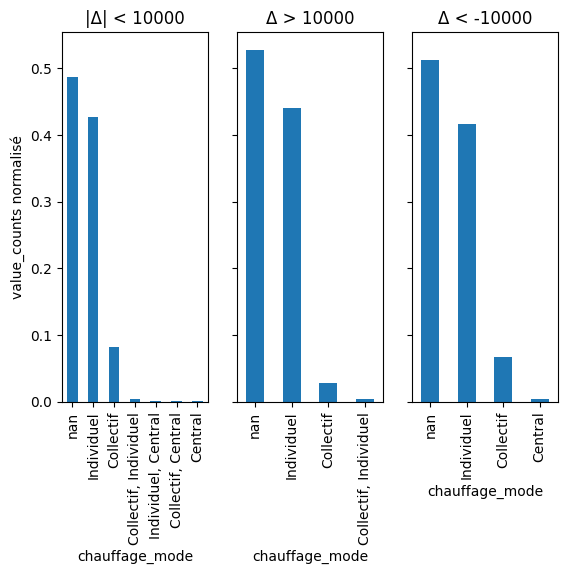



#### Variable  categorie_annonceur  ####
|delta_prediction| < 10000
categorie_annonceur
a          3448
cm          510
m           384
ca          183
network      57
b             5
Name: count, dtype: int64

delta_prediction > 10000
categorie_annonceur
a          215
m           37
cm          27
network      5
ca           4
Name: count, dtype: int64

delta_prediction < -10000
categorie_annonceur
a          194
cm          30
m           22
ca           4
network      1
b            1
Name: count, dtype: int64


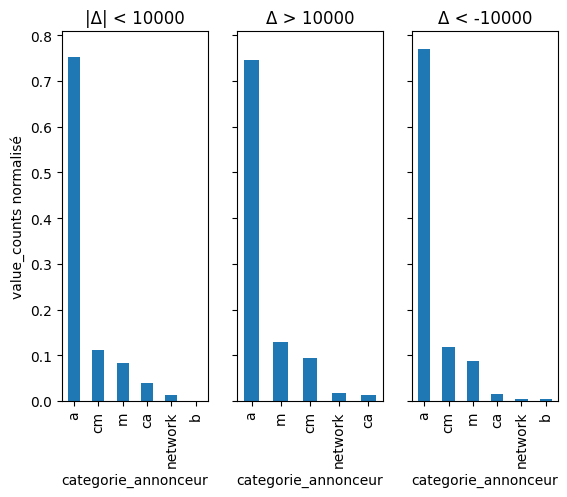



#### Variable  typedebien_lite  ####
|delta_prediction| < 10000
typedebien_lite
a    2388
m    2199
Name: count, dtype: int64

delta_prediction > 10000
typedebien_lite
m    229
a     59
Name: count, dtype: int64

delta_prediction < -10000
typedebien_lite
m    197
a     55
Name: count, dtype: int64


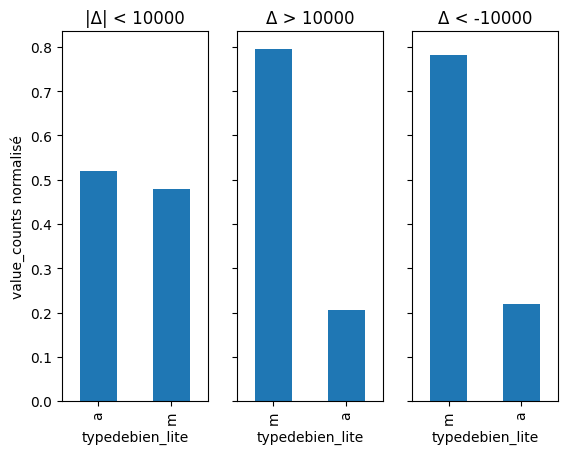



#### Variable  date  ####
|delta_prediction| < 10000
date
2020-01    220
2020-07    181
2021-10    179
2023-02    177
2023-03    177
2022-10    170
2022-09    159
2023-04    151
2022-02    148
2022-05    145
2023-01    143
2022-11    131
2022-07    127
2022-04    127
2022-12    124
2022-06    118
2022-01    117
2021-04    112
2022-03    108
2021-11    104
2021-06    103
2021-09    101
2020-12     99
2022-08     98
2021-02     93
2020-02     93
2020-09     92
2021-12     88
2021-08     86
2021-01     85
2020-06     84
2020-10     79
2021-03     75
2020-05     71
2021-05     69
2021-07     67
2020-03     65
2020-11     59
2020-08     41
2020-04     24
2019-09     23
2019-02     18
2019-11     13
2019-12     13
2019-05      8
2019-04      7
2019-08      5
2019-10      4
2019-06      4
2019-03      1
2019-07      1
Name: count, dtype: int64

delta_prediction > 10000
date
2022-03    15
2020-01    15
2023-04    14
2023-01    13
2022-12    13
2022-11    13
2022-10    12
2022-07    12
2023-0

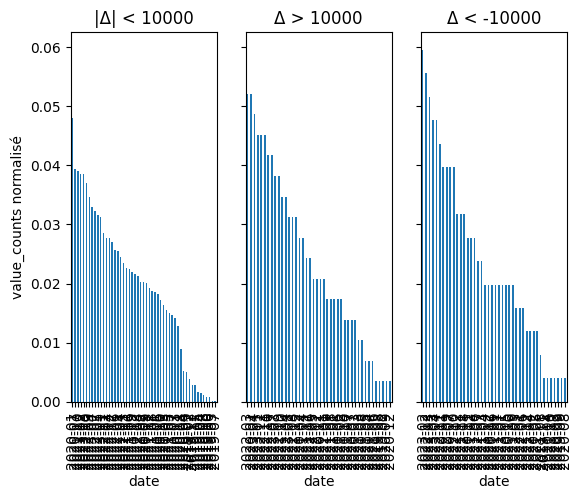



#### Variable  TYP_IRIS_x  ####
|delta_prediction| < 10000
TYP_IRIS_x
H    2298
Z    2287
D       2
Name: count, dtype: int64

delta_prediction > 10000
TYP_IRIS_x
Z    172
H    116
Name: count, dtype: int64

delta_prediction < -10000
TYP_IRIS_x
Z    149
H    103
Name: count, dtype: int64


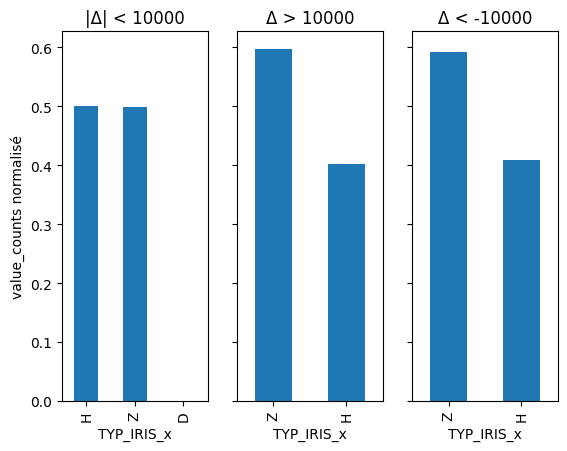



#### Variable  TYP_IRIS_y  ####
|delta_prediction| < 10000
TYP_IRIS_y
H    2300
Z    2287
Name: count, dtype: int64

delta_prediction > 10000
TYP_IRIS_y
Z    172
H    116
Name: count, dtype: int64

delta_prediction < -10000
TYP_IRIS_y
Z    149
H    103
Name: count, dtype: int64


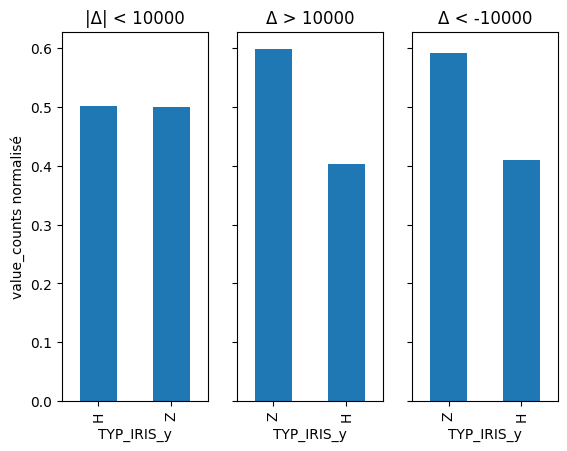

In [111]:
for col in df_tree_diff.select_dtypes(include=['object']).columns[:]:
    plt.Figure()
    print("\n\n#### Variable ", col, " ####")
    print("|delta_prediction| < 10000")
    print(df_tree_diff[np.abs(df_tree_diff['delta_prediction']) <= 10000][col].value_counts())
    print("\ndelta_prediction > 10000")
    print(df_tree_diff[df_tree_diff['delta_prediction'] > 10000][col].value_counts())
    print("\ndelta_prediction < -10000")
    print(df_tree_diff[df_tree_diff['delta_prediction'] < -10000][col].value_counts())
    ax1 = plt.subplot(131)
    df_tree_diff[np.abs(df_tree_diff['delta_prediction']) <= 10000][col].value_counts(dropna=False, normalize=True).plot(kind='bar')
    ax1.set_ylabel("value_counts normalisé")
    plt.title("|Δ| < 10000")
    plt.xticks(rotation=90)
    ax2 = plt.subplot(132, sharey=ax1)
    df_tree_diff[df_tree_diff['delta_prediction'] > 10000][col].value_counts(dropna=False, normalize=True).plot(kind='bar')
    plt.title("Δ > 10000")
    plt.xticks(rotation=90)
    ax3 = plt.subplot(133, sharey=ax1)
    df_tree_diff[df_tree_diff['delta_prediction'] < -10000][col].value_counts(dropna=False, normalize=True).plot(kind='bar')
    plt.title("Δ < -10000")
    plt.xticks(rotation=90)
    plt.show()


On note sur les mauvaises prédictions, en comparaison aux bonnes prédictions, une concentration sur les modalités suivantes :
* typedebien : m
* typedebien_lite : m

## 16.2) Variables numérique



#### Variable  etage  ####
|delta_prediction| < 10000
count    4587.000000
mean        0.568127
std         1.123575
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         6.000000
Name: etage, dtype: float64
delta_prediction > 10000
count    288.000000
mean       0.315972
std        0.991684
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        6.000000
Name: etage, dtype: float64
delta_prediction < -10000
count    252.000000
mean       0.253968
std        0.855603
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        5.000000
Name: etage, dtype: float64


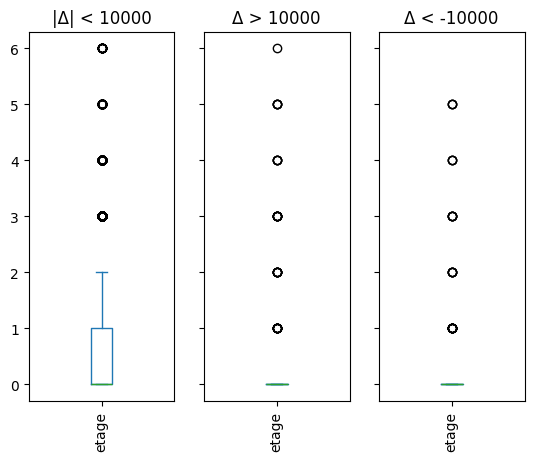



#### Variable  surface  ####
|delta_prediction| < 10000
count    4587.000000
mean       97.795727
std        40.691010
min        12.000000
25%        70.000000
50%        92.000000
75%       119.000000
max       320.000000
Name: surface, dtype: float64
delta_prediction > 10000
count    288.00000
mean     175.87500
std       67.73178
min       31.00000
25%      126.50000
50%      170.00000
75%      208.50000
max      420.00000
Name: surface, dtype: float64
delta_prediction < -10000
count    252.000000
mean     154.666667
std       66.402851
min       12.000000
25%      110.750000
50%      154.000000
75%      200.000000
max      330.000000
Name: surface, dtype: float64


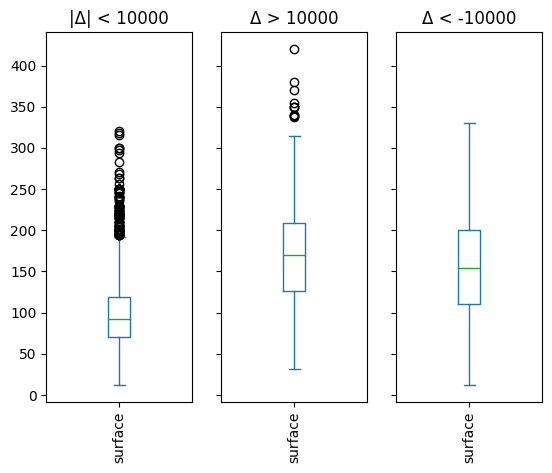



#### Variable  surface_terrain  ####
|delta_prediction| < 10000
count    1844.000000
mean      606.429458
std       416.527031
min         1.480000
25%       348.750000
50%       543.500000
75%       751.250000
max      2783.000000
Name: surface_terrain, dtype: float64
delta_prediction > 10000
count     199.000000
mean      912.628995
std       579.844162
min         9.000000
25%       561.500000
50%       800.000000
75%      1164.000000
max      2779.000000
Name: surface_terrain, dtype: float64
delta_prediction < -10000
count     175.000000
mean      769.988343
std       518.057779
min         4.610000
25%       453.000000
50%       659.000000
75%       985.000000
max      2750.000000
Name: surface_terrain, dtype: float64


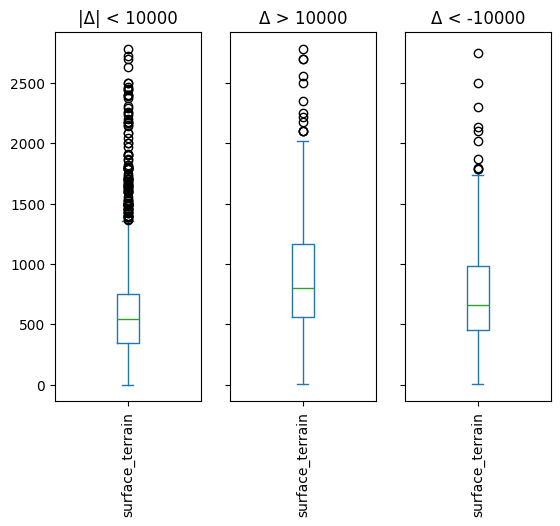



#### Variable  nb_pieces  ####
|delta_prediction| < 10000
count    4587.000000
mean        4.241334
std         1.579127
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max        12.000000
Name: nb_pieces, dtype: float64
delta_prediction > 10000
count    288.000000
mean       6.309028
std        2.064716
min        1.000000
25%        5.000000
50%        6.000000
75%        7.000000
max       12.000000
Name: nb_pieces, dtype: float64
delta_prediction < -10000
count    252.000000
mean       5.940476
std        2.286377
min        1.000000
25%        5.000000
50%        6.000000
75%        7.000000
max       12.000000
Name: nb_pieces, dtype: float64


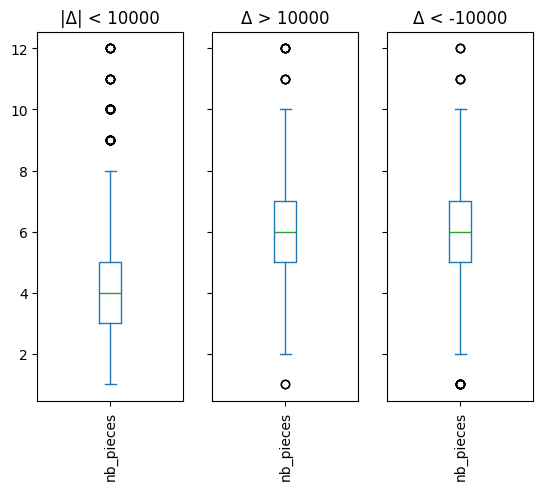



#### Variable  mensualiteFinance  ####
|delta_prediction| < 10000
count    4587.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: mensualiteFinance, dtype: float64
delta_prediction > 10000
count    288.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: mensualiteFinance, dtype: float64
delta_prediction < -10000
count    252.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: mensualiteFinance, dtype: float64


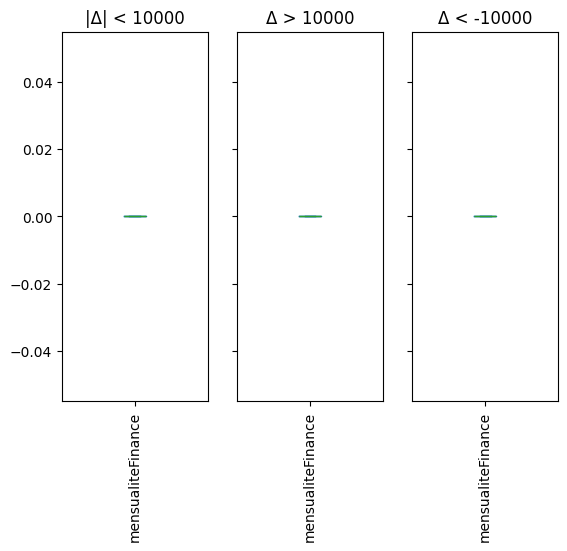



#### Variable  balcon  ####
|delta_prediction| < 10000
count    4587.000000
mean        0.160017
std         0.398577
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         3.000000
Name: balcon, dtype: float64
delta_prediction > 10000
count    288.000000
mean       0.125000
std        0.380262
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        2.000000
Name: balcon, dtype: float64
delta_prediction < -10000
count    252.000000
mean       0.095238
std        0.294128
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: balcon, dtype: float64


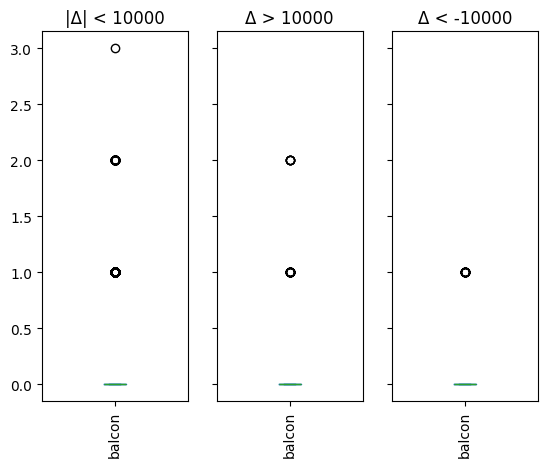



#### Variable  eau  ####
|delta_prediction| < 10000
count    4587.000000
mean        0.281012
std         0.514249
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         3.000000
Name: eau, dtype: float64
delta_prediction > 10000
count    288.000000
mean       0.458333
std        0.702162
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        3.000000
Name: eau, dtype: float64
delta_prediction < -10000
count    252.000000
mean       0.357143
std        0.637029
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        3.000000
Name: eau, dtype: float64


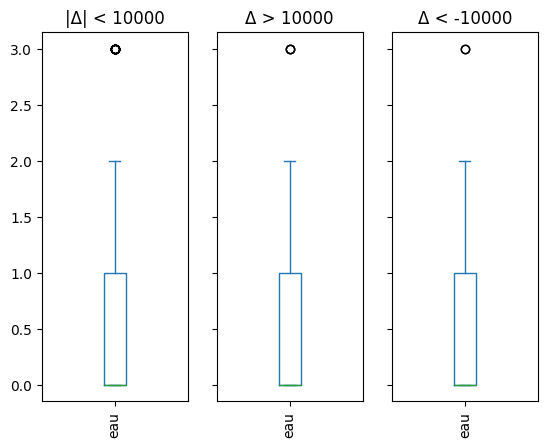



#### Variable  bain  ####
|delta_prediction| < 10000
count    4587.000000
mean        0.630041
std         0.596395
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         3.000000
Name: bain, dtype: float64
delta_prediction > 10000
count    288.000000
mean       0.857639
std        0.861817
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        3.000000
Name: bain, dtype: float64
delta_prediction < -10000
count    252.000000
mean       0.805556
std        0.781948
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        3.000000
Name: bain, dtype: float64


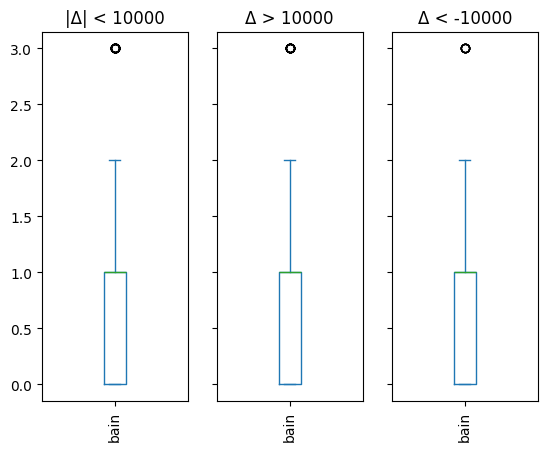



#### Variable  dpeC  ####
|delta_prediction| < 10000
count    2817.000000
mean      207.761029
std        98.495044
min         1.000000
25%       137.000000
50%       199.000000
75%       266.000000
max       689.000000
Name: dpeC, dtype: float64
delta_prediction > 10000
count    206.000000
mean     194.634369
std       95.056857
min        3.000000
25%      129.250000
50%      189.000000
75%      245.750000
max      541.000000
Name: dpeC, dtype: float64
delta_prediction < -10000
count    159.000000
mean     227.797484
std      120.623937
min        6.000000
25%      146.000000
50%      201.000000
75%      281.500000
max      636.000000
Name: dpeC, dtype: float64


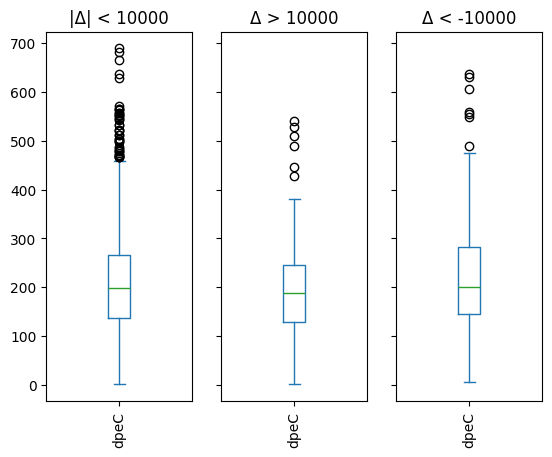



#### Variable  mapCoordonneesLatitude  ####
|delta_prediction| < 10000
count    4587.000000
mean       47.808849
std         0.181697
min        47.448620
25%        47.673075
50%        47.763470
75%        47.941740
max        48.283840
Name: mapCoordonneesLatitude, dtype: float64
delta_prediction > 10000
count    288.000000
mean      47.783857
std        0.191080
min       47.429600
25%       47.627165
50%       47.743200
75%       47.936372
max       48.271310
Name: mapCoordonneesLatitude, dtype: float64
delta_prediction < -10000
count    252.000000
mean      47.784967
std        0.183141
min       47.482490
25%       47.635872
50%       47.749420
75%       47.894033
max       48.247670
Name: mapCoordonneesLatitude, dtype: float64


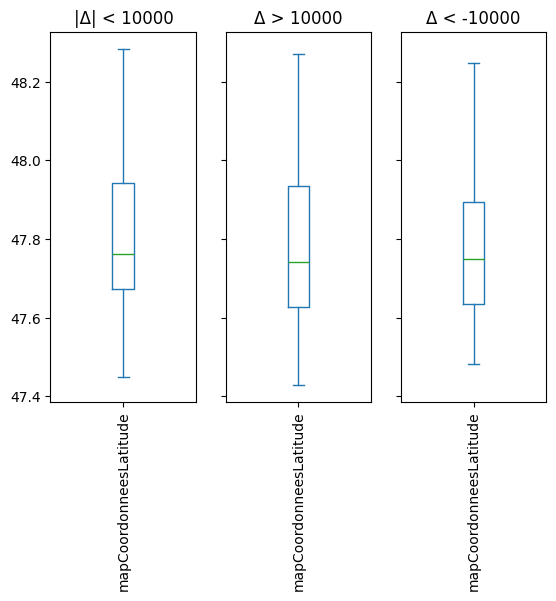



#### Variable  mapCoordonneesLongitude  ####
|delta_prediction| < 10000
count    4587.000000
mean        7.341955
std         0.126920
min         6.904880
25%         7.278735
50%         7.342370
75%         7.406990
max         7.588670
Name: mapCoordonneesLongitude, dtype: float64
delta_prediction > 10000
count    288.000000
mean       7.333234
std        0.137603
min        6.903600
25%        7.242778
50%        7.332295
75%        7.412538
max        7.592830
Name: mapCoordonneesLongitude, dtype: float64
delta_prediction < -10000
count    252.000000
mean       7.320408
std        0.152215
min        6.904780
25%        7.236130
50%        7.342460
75%        7.400173
max        7.588610
Name: mapCoordonneesLongitude, dtype: float64


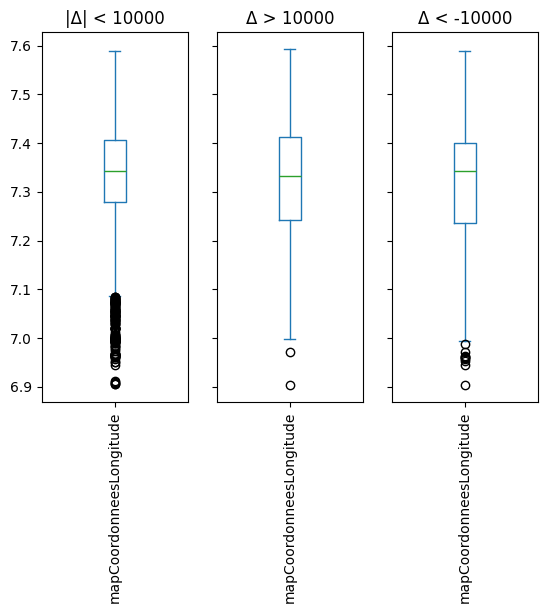



#### Variable  nb_etages  ####
|delta_prediction| < 10000
count      2512.0
mean     2.520701
std       1.39049
min           0.0
25%           2.0
50%           2.0
75%           3.0
max          10.0
Name: nb_etages, dtype: Float64
delta_prediction > 10000
count       144.0
mean     2.076389
std      1.090838
min           1.0
25%           1.0
50%           2.0
75%           3.0
max           6.0
Name: nb_etages, dtype: Float64
delta_prediction < -10000
count       111.0
mean     2.261261
std      1.109559
min           1.0
25%           2.0
50%           2.0
75%           3.0
max           7.0
Name: nb_etages, dtype: Float64


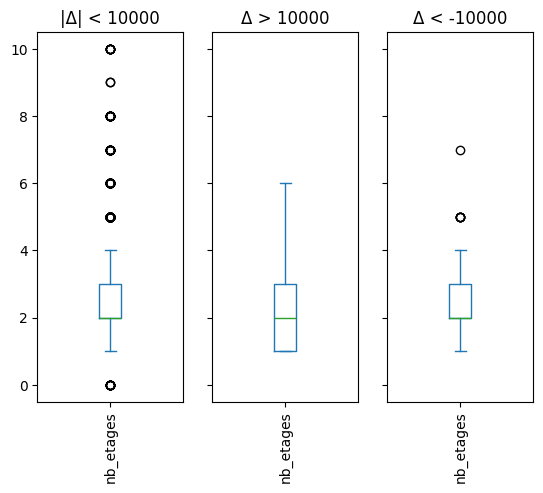



#### Variable  places_parking  ####
|delta_prediction| < 10000
count      1696.0
mean     1.821934
std      1.172503
min           0.0
25%           1.0
50%           1.0
75%           2.0
max           7.0
Name: places_parking, dtype: Float64
delta_prediction > 10000
count       131.0
mean      2.40458
std      1.385522
min           0.0
25%           1.0
50%           2.0
75%           3.0
max           7.0
Name: places_parking, dtype: Float64
delta_prediction < -10000
count        96.0
mean      2.59375
std      1.559879
min           0.0
25%           1.0
50%           2.0
75%           4.0
max           7.0
Name: places_parking, dtype: Float64


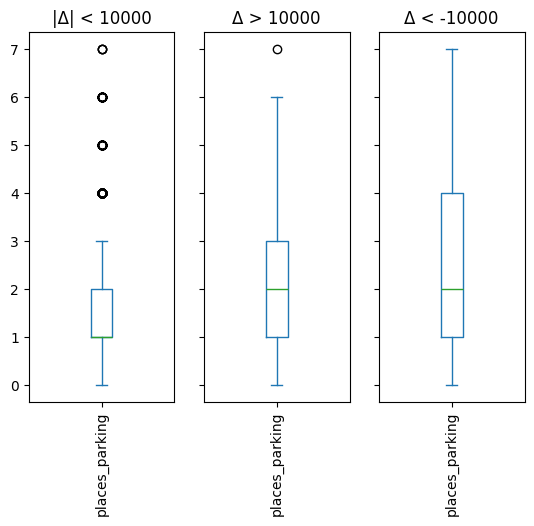



#### Variable  cave  ####
|delta_prediction| < 10000
count      2255.0
mean     0.652328
std      0.476337
min           0.0
25%           0.0
50%           1.0
75%           1.0
max           1.0
Name: cave, dtype: Float64
delta_prediction > 10000
count       132.0
mean     0.606061
std      0.490483
min           0.0
25%           0.0
50%           1.0
75%           1.0
max           1.0
Name: cave, dtype: Float64
delta_prediction < -10000
count       114.0
mean     0.622807
std      0.486824
min           0.0
25%           0.0
50%           1.0
75%           1.0
max           1.0
Name: cave, dtype: Float64


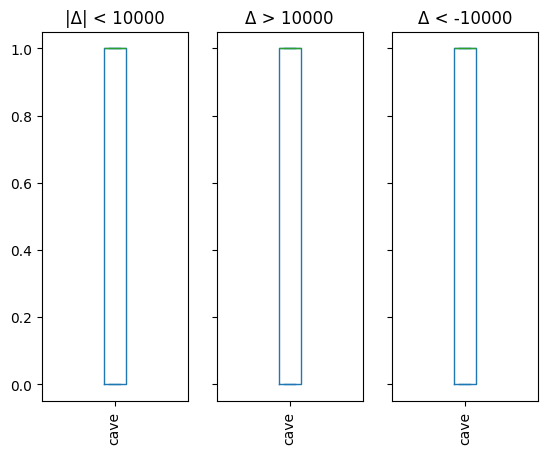



#### Variable  annee_construction  ####
|delta_prediction| < 10000
count         1585.0
mean     1975.114826
std        42.326377
min           1749.0
25%           1955.0
50%           1980.0
75%           2008.0
max           2025.0
Name: annee_construction, dtype: Float64
delta_prediction > 10000
count          116.0
mean     1967.155172
std         51.81952
min           1800.0
25%           1949.5
50%           1978.5
75%           2005.0
max           2022.0
Name: annee_construction, dtype: Float64
delta_prediction < -10000
count           98.0
mean     1957.091837
std        52.924589
min           1750.0
25%           1923.0
50%           1970.0
75%           2001.0
max           2022.0
Name: annee_construction, dtype: Float64


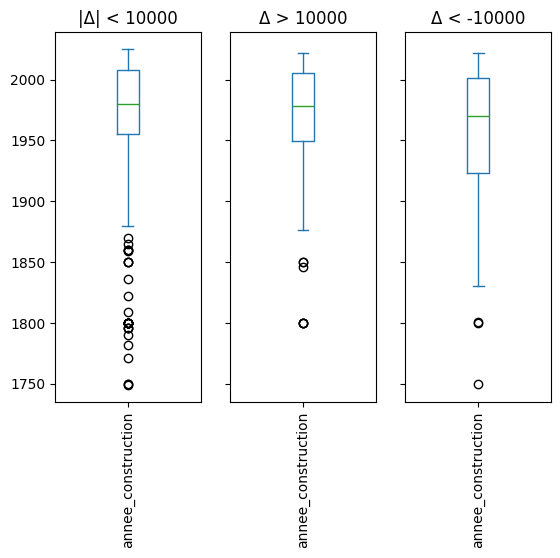



#### Variable  nb_toilettes  ####
|delta_prediction| < 10000
count      2587.0
mean     1.396598
std      0.590296
min           0.0
25%           1.0
50%           1.0
75%           2.0
max           4.0
Name: nb_toilettes, dtype: Float64
delta_prediction > 10000
count       174.0
mean     2.091954
std      0.769839
min           1.0
25%           2.0
50%           2.0
75%           2.0
max           4.0
Name: nb_toilettes, dtype: Float64
delta_prediction < -10000
count       148.0
mean     1.837838
std      0.728936
min           0.0
25%           1.0
50%           2.0
75%           2.0
max           4.0
Name: nb_toilettes, dtype: Float64


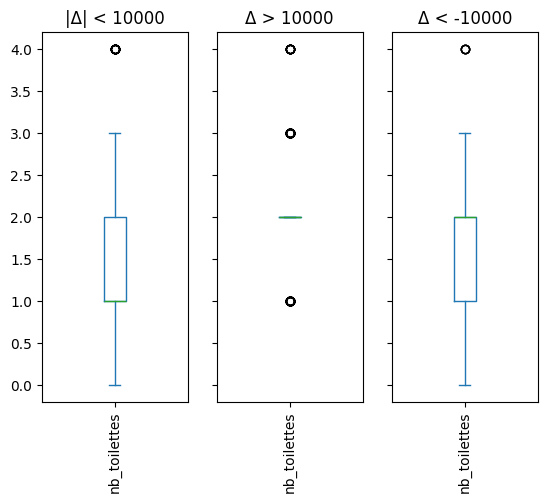



#### Variable  ascenseur  ####
|delta_prediction| < 10000
count      1502.0
mean     0.534621
std      0.498966
min           0.0
25%           0.0
50%           1.0
75%           1.0
max           1.0
Name: ascenseur, dtype: Float64
delta_prediction > 10000
count        34.0
mean     0.647059
std      0.485071
min           0.0
25%           0.0
50%           1.0
75%           1.0
max           1.0
Name: ascenseur, dtype: Float64
delta_prediction < -10000
count        36.0
mean     0.638889
std      0.487136
min           0.0
25%           0.0
50%           1.0
75%           1.0
max           1.0
Name: ascenseur, dtype: Float64


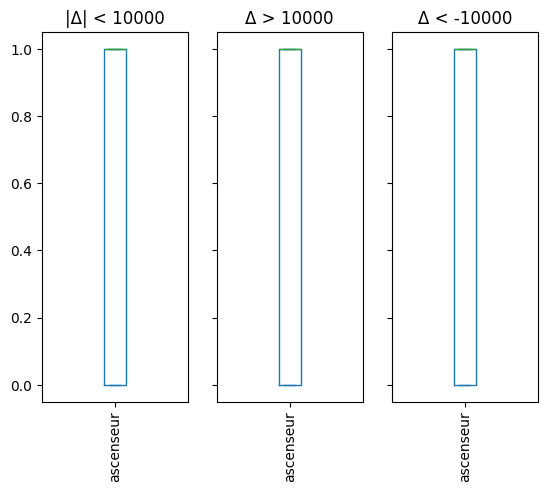



#### Variable  nb_logements_copro  ####
|delta_prediction| < 10000
count       1310.0
mean     38.924427
std      44.404364
min            0.0
25%            9.0
50%           21.0
75%           51.0
max          232.0
Name: nb_logements_copro, dtype: Float64
delta_prediction > 10000
count         36.0
mean     37.777778
std      50.547353
min            2.0
25%           8.75
50%           16.5
75%           43.5
max          193.0
Name: nb_logements_copro, dtype: Float64
delta_prediction < -10000
count         24.0
mean     27.708333
std      41.922785
min            1.0
25%           4.25
50%           12.0
75%          29.25
max          166.0
Name: nb_logements_copro, dtype: Float64


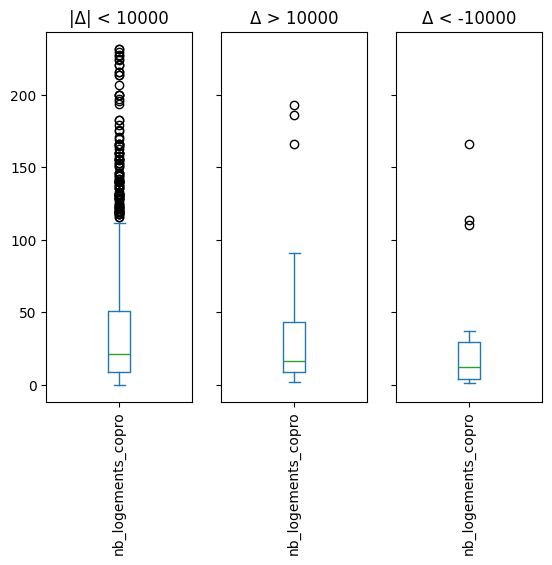



#### Variable  charges_copro  ####
|delta_prediction| < 10000
count    1205.000000
mean     1282.108357
std       911.059533
min         0.000000
25%       600.000000
50%      1152.000000
75%      1828.680000
max      4560.000000
Name: charges_copro, dtype: float64
delta_prediction > 10000
count      25.000000
mean     1716.160000
std      1359.103555
min         0.000000
25%       400.000000
50%      1520.000000
75%      2712.000000
max      3900.000000
Name: charges_copro, dtype: float64
delta_prediction < -10000
count      19.000000
mean     1648.896842
std      1028.618045
min         0.000000
25%      1017.000000
50%      1536.000000
75%      1903.000000
max      3900.000000
Name: charges_copro, dtype: float64


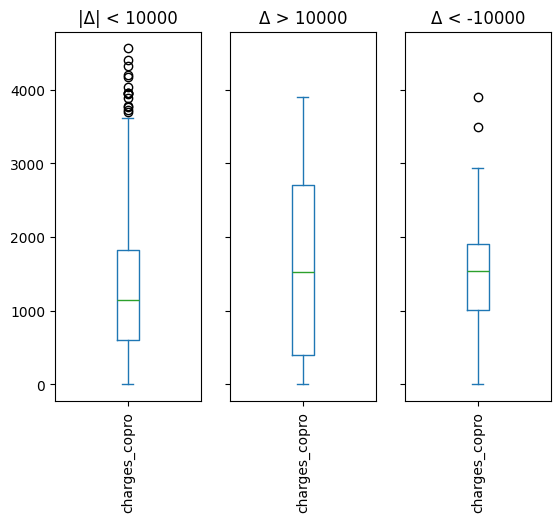



#### Variable  logement_neuf  ####
|delta_prediction| < 10000
count      4471.0
mean     0.139566
std      0.346575
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           1.0
Name: logement_neuf, dtype: Float64
delta_prediction > 10000
count       286.0
mean     0.094406
std      0.292905
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           1.0
Name: logement_neuf, dtype: Float64
delta_prediction < -10000
count       244.0
mean     0.114754
std       0.31938
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           1.0
Name: logement_neuf, dtype: Float64


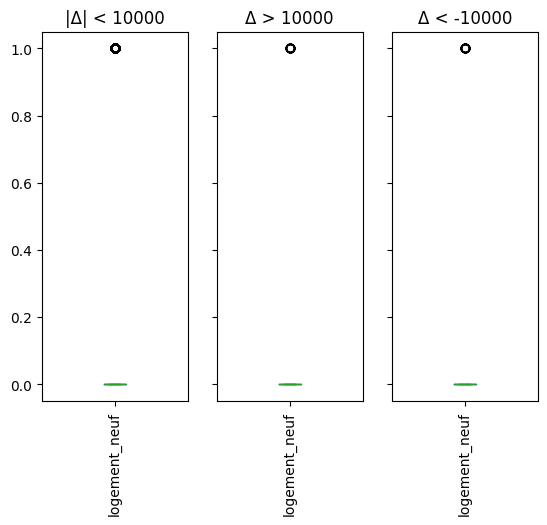



#### Variable  duree_int  ####
|delta_prediction| < 10000
count        4346.0
mean    -125.635987
std      394.452173
min         -1125.0
25%             6.0
50%            22.0
75%            75.0
max           568.0
Name: duree_int, dtype: Float64
delta_prediction > 10000
count         273.0
mean     -63.208791
std      342.752789
min         -1062.0
25%            10.0
50%            43.0
75%           106.0
max           562.0
Name: duree_int, dtype: Float64
delta_prediction < -10000
count        235.0
mean    -68.114894
std      357.22616
min        -1070.0
25%            8.0
50%           36.0
75%           99.5
max          358.0
Name: duree_int, dtype: Float64


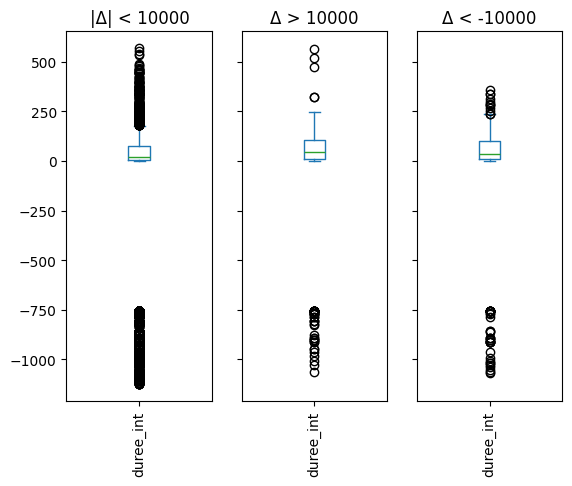



#### Variable  INSEE_COM  ####
|delta_prediction| < 10000
count     4587.000000
mean     68192.070852
std        106.183647
min      68001.000000
25%      68082.000000
50%      68217.000000
75%      68278.000000
max      68386.000000
Name: INSEE_COM, dtype: float64
delta_prediction > 10000
count      288.000000
mean     68191.833333
std        109.529656
min      68004.000000
25%      68092.750000
50%      68196.000000
75%      68287.000000
max      68384.000000
Name: INSEE_COM, dtype: float64
delta_prediction < -10000
count      252.000000
mean     68200.702381
std        107.539128
min      68004.000000
25%      68119.000000
50%      68224.000000
75%      68297.000000
max      68386.000000
Name: INSEE_COM, dtype: float64


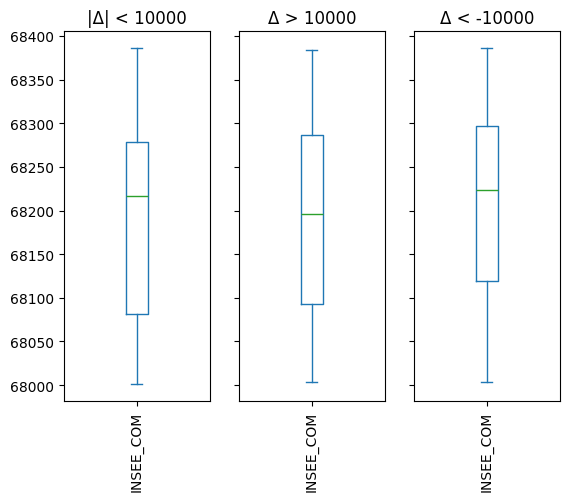



#### Variable  IRIS  ####
|delta_prediction| < 10000
count    4587.000000
mean      170.840201
std       333.547446
min         0.000000
25%         0.000000
50%       101.000000
75%       104.000000
max      1802.000000
Name: IRIS, dtype: float64
delta_prediction > 10000
count     288.000000
mean      114.434028
std       280.103333
min         0.000000
25%         0.000000
50%         0.000000
75%       102.000000
max      1703.000000
Name: IRIS, dtype: float64
delta_prediction < -10000
count     252.000000
mean      121.563492
std       245.491182
min         0.000000
25%         0.000000
50%         0.000000
75%       102.000000
max      1203.000000
Name: IRIS, dtype: float64


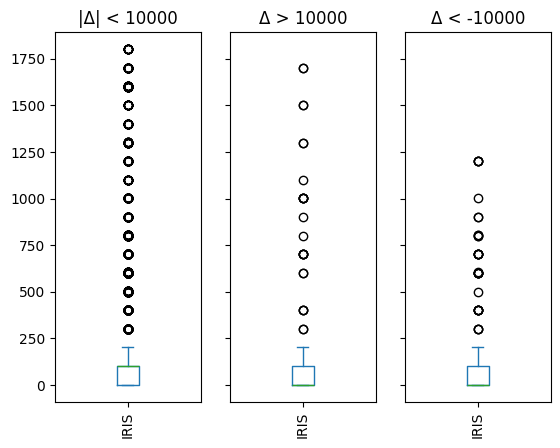



#### Variable  CODE_IRIS  ####
|delta_prediction| < 10000
count    4.587000e+03
mean     6.819209e+08
std      1.061821e+06
min      6.800100e+08
25%      6.808200e+08
50%      6.821700e+08
75%      6.827801e+08
max      6.838600e+08
Name: CODE_IRIS, dtype: float64
delta_prediction > 10000
count    2.880000e+02
mean     6.819184e+08
std      1.095311e+06
min      6.800401e+08
25%      6.809275e+08
50%      6.819601e+08
75%      6.828700e+08
max      6.838400e+08
Name: CODE_IRIS, dtype: float64
delta_prediction < -10000
count    2.520000e+02
mean     6.820071e+08
std      1.075366e+06
min      6.800401e+08
25%      6.811900e+08
50%      6.822401e+08
75%      6.829701e+08
max      6.838600e+08
Name: CODE_IRIS, dtype: float64


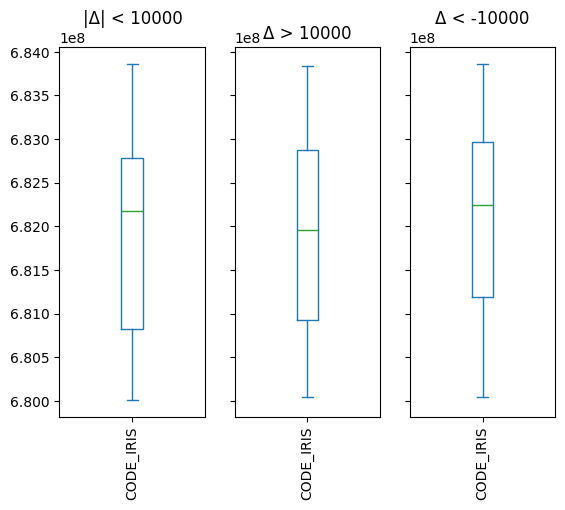



#### Variable  GRD_QUART  ####
|delta_prediction| < 10000
count    4.587000e+03
mean     6.819208e+06
std      1.061837e+04
min      6.800100e+06
25%      6.808200e+06
50%      6.821700e+06
75%      6.827801e+06
max      6.838600e+06
Name: GRD_QUART, dtype: float64
delta_prediction > 10000
count    2.880000e+02
mean     6.819184e+06
std      1.095300e+04
min      6.800401e+06
25%      6.809275e+06
50%      6.819600e+06
75%      6.828700e+06
max      6.838400e+06
Name: GRD_QUART, dtype: float64
delta_prediction < -10000
count    2.520000e+02
mean     6.820071e+06
std      1.075391e+04
min      6.800401e+06
25%      6.811900e+06
50%      6.822401e+06
75%      6.829701e+06
max      6.838600e+06
Name: GRD_QUART, dtype: float64


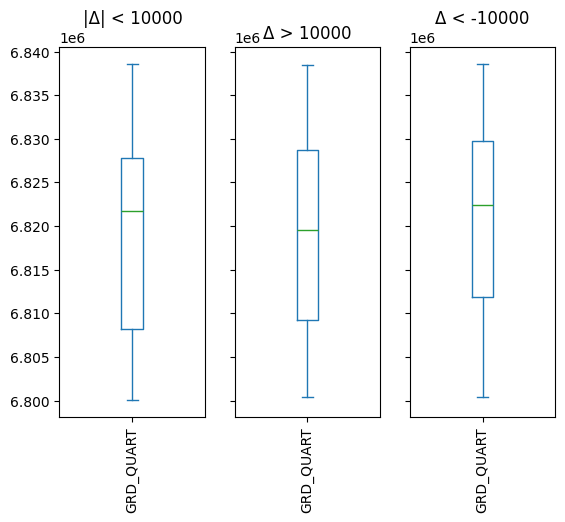



#### Variable  UU2010  ####
|delta_prediction| < 10000
count     4587.000000
mean     68371.118378
std        268.284199
min      68000.000000
25%      68113.000000
50%      68403.000000
75%      68701.000000
max      68701.000000
Name: UU2010, dtype: float64
delta_prediction > 10000
count      288.000000
mean     68308.815972
std        272.000546
min      68000.000000
25%      68000.000000
50%      68301.500000
75%      68501.000000
max      68701.000000
Name: UU2010, dtype: float64
delta_prediction < -10000
count      252.000000
mean     68305.341270
std        265.516565
min      68000.000000
25%      68000.000000
50%      68207.000000
75%      68501.000000
max      68701.000000
Name: UU2010, dtype: float64


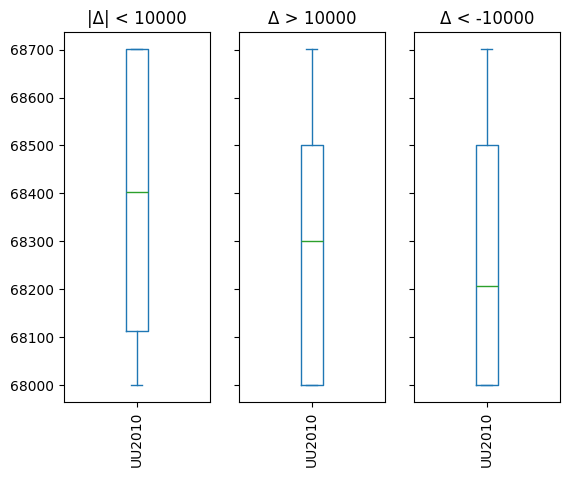



#### Variable  REG  ####
|delta_prediction| < 10000
count    4587.0
mean       44.0
std         0.0
min        44.0
25%        44.0
50%        44.0
75%        44.0
max        44.0
Name: REG, dtype: float64
delta_prediction > 10000
count    288.0
mean      44.0
std        0.0
min       44.0
25%       44.0
50%       44.0
75%       44.0
max       44.0
Name: REG, dtype: float64
delta_prediction < -10000
count    252.0
mean      44.0
std        0.0
min       44.0
25%       44.0
50%       44.0
75%       44.0
max       44.0
Name: REG, dtype: float64


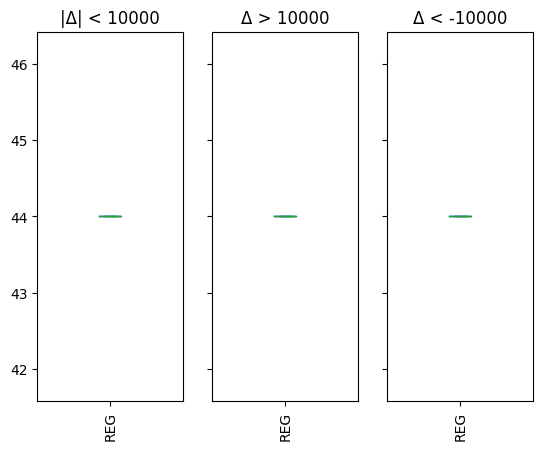



#### Variable  DEP  ####
|delta_prediction| < 10000
count    4587.0
mean       68.0
std         0.0
min        68.0
25%        68.0
50%        68.0
75%        68.0
max        68.0
Name: DEP, dtype: float64
delta_prediction > 10000
count    288.0
mean      68.0
std        0.0
min       68.0
25%       68.0
50%       68.0
75%       68.0
max       68.0
Name: DEP, dtype: float64
delta_prediction < -10000
count    252.0
mean      68.0
std        0.0
min       68.0
25%       68.0
50%       68.0
75%       68.0
max       68.0
Name: DEP, dtype: float64


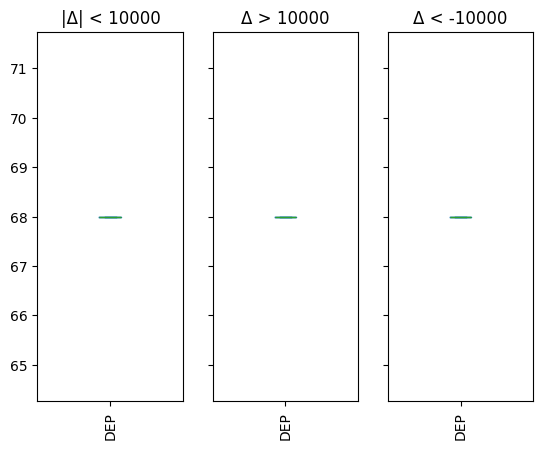



#### Variable  loyer_m2_median_n7  ####
|delta_prediction| < 10000
count    3385.000000
mean       10.665111
std         1.883489
min         4.780000
25%         9.440000
50%        10.460000
75%        11.810000
max        19.670000
Name: loyer_m2_median_n7, dtype: float64
delta_prediction > 10000
count    141.000000
mean       9.939574
std        2.171514
min        5.260000
25%        8.570000
50%        9.430000
75%       11.660000
max       17.570000
Name: loyer_m2_median_n7, dtype: float64
delta_prediction < -10000
count    130.000000
mean      10.782462
std        2.743623
min        6.310000
25%        8.695000
50%       10.060000
75%       13.120000
max       18.750000
Name: loyer_m2_median_n7, dtype: float64


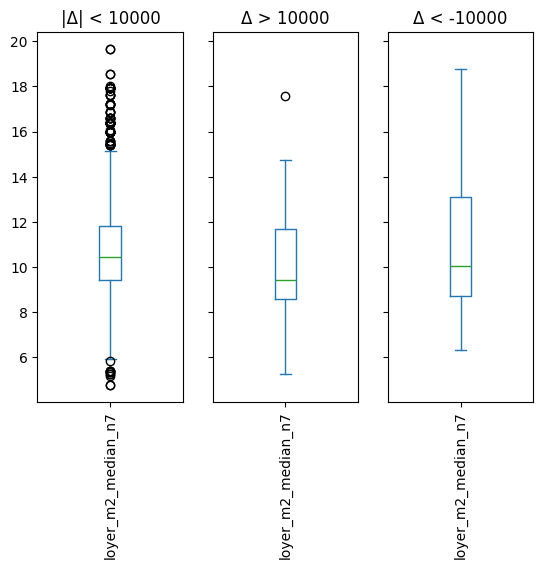



#### Variable  nb_log_n7  ####
|delta_prediction| < 10000
count        3385.0
mean     147.348892
std      253.643464
min             1.0
25%             3.0
50%            17.0
75%           149.0
max           960.0
Name: nb_log_n7, dtype: Float64
delta_prediction > 10000
count         141.0
mean      50.283688
std      138.040901
min             1.0
25%             1.0
50%             3.0
75%            11.0
max           839.0
Name: nb_log_n7, dtype: Float64
delta_prediction < -10000
count         130.0
mean      67.107692
std      169.420364
min             1.0
25%             1.0
50%             3.0
75%            12.5
max           839.0
Name: nb_log_n7, dtype: Float64


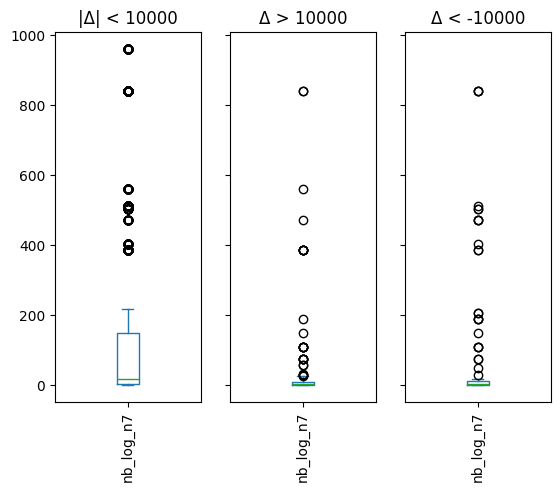



#### Variable  taux_rendement_n7  ####
|delta_prediction| < 10000
count    3385.000000
mean        0.055357
std         0.024775
min         0.018000
25%         0.039000
50%         0.048000
75%         0.065000
max         0.357000
Name: taux_rendement_n7, dtype: float64
delta_prediction > 10000
count    141.000000
mean       0.040567
std        0.019547
min        0.010000
25%        0.027000
50%        0.035000
75%        0.050000
max        0.123000
Name: taux_rendement_n7, dtype: float64
delta_prediction < -10000
count    130.000000
mean       0.054023
std        0.049022
min        0.012000
25%        0.030000
50%        0.037500
75%        0.059000
max        0.384000
Name: taux_rendement_n7, dtype: float64


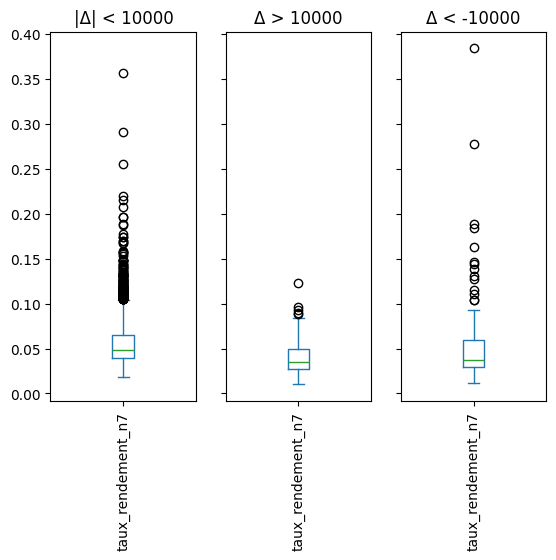



#### Variable  prix_m2_vente  ####
|delta_prediction| < 10000
count    4587.000000
mean     2608.856444
std       903.104322
min       471.830000
25%      1944.945000
50%      2619.050000
75%      3239.130000
max      6780.820000
Name: prix_m2_vente, dtype: float64
delta_prediction > 10000
count     288.000000
mean     3037.552569
std      1423.980092
min       583.940000
25%      1875.000000
50%      2807.460000
75%      3948.395000
max      7626.510000
Name: prix_m2_vente, dtype: float64
delta_prediction < -10000
count     252.000000
mean     2767.692341
std      1521.998713
min        96.670000
25%      1413.170000
50%      2638.935000
75%      3846.352500
max      7800.000000
Name: prix_m2_vente, dtype: float64


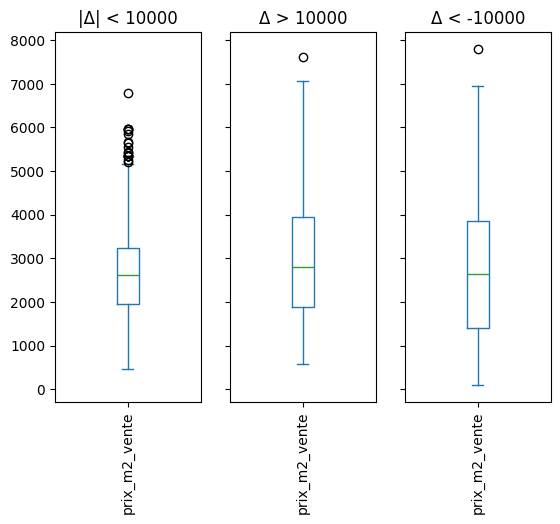

In [112]:
for col in df_tree_diff.select_dtypes(exclude=['object']).columns[:]:
    if col != 'delta_prediction' and col != 'prix_bien_y':
        plt.Figure()
        print("\n\n#### Variable ", col, " ####")
        print("|delta_prediction| < 10000")
        print(df_tree_diff[np.abs(df_tree_diff['delta_prediction']) <= 10000][col].describe())
        print("delta_prediction > 10000")
        print(df_tree_diff[df_tree_diff['delta_prediction'] > 10000][col].describe())
        print("delta_prediction < -10000")
        print(df_tree_diff[df_tree_diff['delta_prediction'] < -10000][col].describe())
        ax1 = plt.subplot(131)
        df_tree_diff[np.abs(df_tree_diff['delta_prediction']) <= 10000][col].plot(kind='box')
        plt.title("|Δ| < 10000")
        plt.xticks(rotation=90)
        ax2 = plt.subplot(132, sharey=ax1)
        df_tree_diff[df_tree_diff['delta_prediction'] > 10000][col].plot(kind='box', )
        plt.title("Δ > 10000")
        plt.xticks(rotation=90)
        ax3 = plt.subplot(133, sharey=ax1)
        df_tree_diff[df_tree_diff['delta_prediction'] < -10000][col].plot(kind='box', )
        plt.title("Δ < -10000")
        plt.xticks(rotation=90)
        plt.show()


On note sur les mauvaises prédictions, en comparaison aux bonnes prédictions, une distribution plus élevée sur les features suivantes :
* surface : P50 à 92 vs 166 sur les mauvaises prédiction
* surface_terrain : P50 à 543 vs 750 sur les mauvaises prédiction (! beaucoup de NaN)
* nb_pieces : P50 à 4 vs 6 sur les mauvaises prédictions

## 16.3) Variables identifié



#### Variable  typedebien_lite  ####
|delta_prediction| < 10000
typedebien_lite
a    2388
m    2199
Name: count, dtype: int64

delta_prediction > 10000
typedebien_lite
m    229
a     59
Name: count, dtype: int64

delta_prediction < -10000
typedebien_lite
m    197
a     55
Name: count, dtype: int64


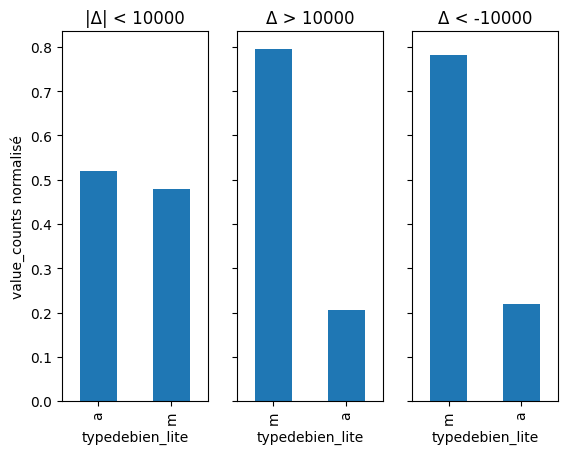

In [113]:
for col in ['typedebien_lite']:
    plt.Figure()
    print("\n\n#### Variable ", col, " ####")
    print("|delta_prediction| < 10000")
    print(df_tree_diff[np.abs(df_tree_diff['delta_prediction']) <= 10000][col].value_counts())
    print("\ndelta_prediction > 10000")
    print(df_tree_diff[df_tree_diff['delta_prediction'] > 10000][col].value_counts())
    print("\ndelta_prediction < -10000")
    print(df_tree_diff[df_tree_diff['delta_prediction'] < -10000][col].value_counts())
    ax1 = plt.subplot(131)
    df_tree_diff[np.abs(df_tree_diff['delta_prediction']) <= 10000][col].value_counts(dropna=False, normalize=True).plot(kind='bar')
    ax1.set_ylabel("value_counts normalisé")
    plt.title("|Δ| < 10000")
    plt.xticks(rotation=90)
    ax2 = plt.subplot(132, sharey=ax1)
    df_tree_diff[df_tree_diff['delta_prediction'] > 10000][col].value_counts(dropna=False, normalize=True).plot(kind='bar')
    plt.title("Δ > 10000")
    plt.xticks(rotation=90)
    ax3 = plt.subplot(133, sharey=ax1)
    df_tree_diff[df_tree_diff['delta_prediction'] < -10000][col].value_counts(dropna=False, normalize=True).plot(kind='bar')
    plt.title("Δ < -10000")
    plt.xticks(rotation=90)
    plt.show()




#### Variable  surface  ####
|delta_prediction| < 10000
count    4587.000000
mean       97.795727
std        40.691010
min        12.000000
25%        70.000000
50%        92.000000
75%       119.000000
max       320.000000
Name: surface, dtype: float64
delta_prediction > 10000
count    288.00000
mean     175.87500
std       67.73178
min       31.00000
25%      126.50000
50%      170.00000
75%      208.50000
max      420.00000
Name: surface, dtype: float64
delta_prediction < -10000
count    252.000000
mean     154.666667
std       66.402851
min       12.000000
25%      110.750000
50%      154.000000
75%      200.000000
max      330.000000
Name: surface, dtype: float64


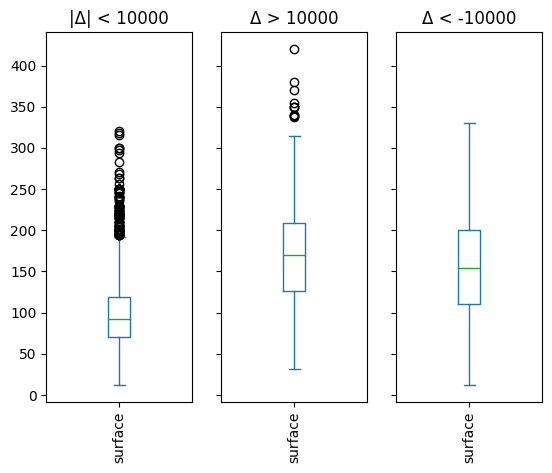



#### Variable  surface_terrain  ####
|delta_prediction| < 10000
count    4587.000000
mean      243.788079
std       397.681003
min         0.000000
25%         0.000000
50%         0.000000
75%       462.500000
max      2783.000000
Name: surface_terrain, dtype: float64
delta_prediction > 10000
count     288.000000
mean      630.601285
std       640.642530
min         0.000000
25%         0.000000
50%       582.500000
75%       977.750000
max      2779.000000
Name: surface_terrain, dtype: float64
delta_prediction < -10000
count     252.000000
mean      534.714127
std       558.888741
min         0.000000
25%         0.000000
50%       480.000000
75%       826.500000
max      2750.000000
Name: surface_terrain, dtype: float64


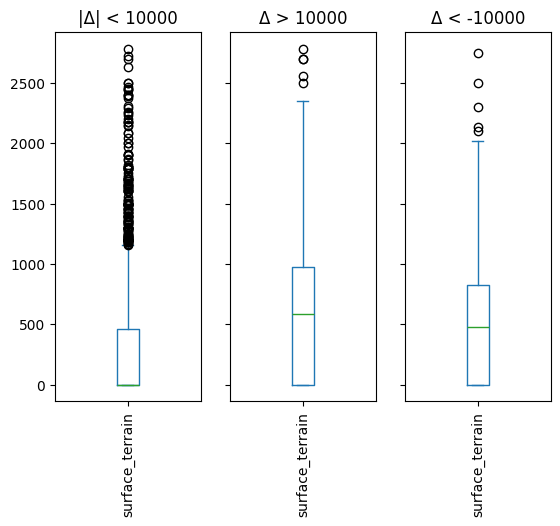



#### Variable  nb_pieces  ####
|delta_prediction| < 10000
count    4587.000000
mean        4.241334
std         1.579127
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max        12.000000
Name: nb_pieces, dtype: float64
delta_prediction > 10000
count    288.000000
mean       6.309028
std        2.064716
min        1.000000
25%        5.000000
50%        6.000000
75%        7.000000
max       12.000000
Name: nb_pieces, dtype: float64
delta_prediction < -10000
count    252.000000
mean       5.940476
std        2.286377
min        1.000000
25%        5.000000
50%        6.000000
75%        7.000000
max       12.000000
Name: nb_pieces, dtype: float64


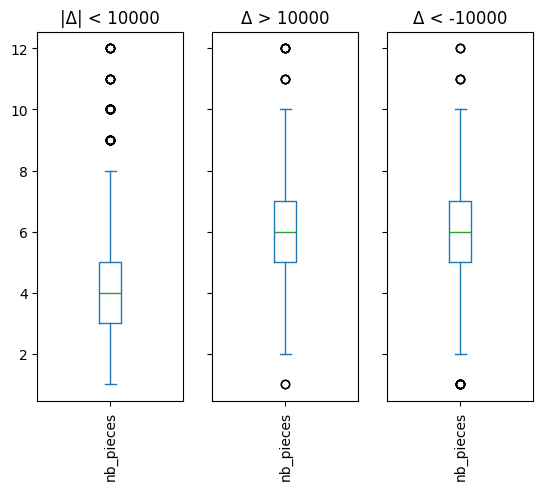

In [114]:
df_boxplot = df_tree_diff.fillna(0) # On remplie les NaN avec 0 dans le jeu de données initiale pour le boxplot
for col in ['surface', 'surface_terrain', 'nb_pieces']:
    if col != 'delta_prediction' and col != 'prix_bien_y':
        plt.Figure()
        print("\n\n#### Variable ", col, " ####")
        print("|delta_prediction| < 10000")
        print(df_boxplot[np.abs(df_boxplot['delta_prediction']) <= 10000][col].describe())
        print("delta_prediction > 10000")
        print(df_boxplot[df_boxplot['delta_prediction'] > 10000][col].describe())
        print("delta_prediction < -10000")
        print(df_boxplot[df_boxplot['delta_prediction'] < -10000][col].describe())
        ax1 = plt.subplot(131)
        df_boxplot[np.abs(df_boxplot['delta_prediction']) <= 10000][col].plot(kind='box')
        plt.title("|Δ| < 10000")
        plt.xticks(rotation=90)
        ax2 = plt.subplot(132, sharey=ax1)
        df_boxplot[df_boxplot['delta_prediction'] > 10000][col].plot(kind='box', )
        plt.title("Δ > 10000")
        plt.xticks(rotation=90)
        ax3 = plt.subplot(133, sharey=ax1)
        df_boxplot[df_boxplot['delta_prediction'] < -10000][col].plot(kind='box', )
        plt.title("Δ < -10000")
        plt.xticks(rotation=90)
        plt.show()


## 16.4) Longitude / Latitude

In [115]:
# --- Calculs de base
lat_long_mean = [df_tree_diff['mapCoordonneesLatitude'].mean(),
                 df_tree_diff['mapCoordonneesLongitude'].mean()]
min_lat = df_tree_diff['mapCoordonneesLatitude'].min()
max_lat = df_tree_diff['mapCoordonneesLatitude'].max()
min_lon = df_tree_diff['mapCoordonneesLongitude'].min()
max_lon = df_tree_diff['mapCoordonneesLongitude'].max()

# --- Seuils
low_thr = -10000
high_thr = 10000

# --- Comptages (avec priorités)
n_mid = ((df_tree_diff['delta_prediction'] >= low_thr) & (df_tree_diff['delta_prediction'] <= high_thr)).sum()
n_low = (df_tree_diff['delta_prediction'] < low_thr).sum()
n_high = (df_tree_diff['delta_prediction'] > high_thr).sum()

label_low = f"Delta (-∞ ; {low_thr}) | n={n_low}"
label_mid = f"Delta [{low_thr} ; {high_thr}] | n={n_mid}"
label_high = f"Delta ({high_thr} ; +∞) | n={n_high}"

# --- Couleurs
color_low = "#de2d26"
color_mid = "#3182bd"
color_high = "#de2d26"

# --- Carte
m = folium.Map(
    location=lat_long_mean,
    tiles="Cartodb Positron",
    min_lat=min_lat,
    min_lon=min_lon,
    max_lat=max_lat,
    max_lon=max_lon,
    zoom_control=True,
    zoom_start=10
)

# --- Groupes
groupes = {
    label_low: folium.FeatureGroup(name=label_low).add_to(m),
    label_mid: folium.FeatureGroup(name=label_mid).add_to(m),
    label_high: folium.FeatureGroup(name=label_high).add_to(m)
}

# --- Ajout des marqueurs
for index, row in df_tree_diff.iterrows():
    val = row['delta_prediction']
    lat = row['mapCoordonneesLatitude']
    lon = row['mapCoordonneesLongitude']

    # Priorité : groupe central d'abord
    if low_thr <= val <= high_thr:
        groupe = label_mid
        couleur = color_mid
    elif val < low_thr:
        groupe = label_low
        couleur = color_low
    else:
        groupe = label_high
        couleur = color_high

    folium.CircleMarker(
        location=[lat, lon],
        radius=7,
        stroke=False,
        fill=True,
        fill_opacity=0.6,
        opacity=1,
        fill_color=couleur,
        color=couleur,
        popup=f"Delta prediction: {val}"
    ).add_to(groupes[groupe])

LayerControl().add_to(m)

m